---
numbering: false
---

# 3.2: Matrix-vector multiplication

The next operation after addition and scalar multiplication is **matrix multiplication**: how do we multiply matrices to form a product like $AB$? We'll get there eventually, but first let's consider a simpler task: multiplying a matrix $A$ by a vector $\vec v$.


---

## A first example

Consider

$$A=\begin{bmatrix}4&-3&5\\-2&6&7\end{bmatrix},\qquad
\vec v=\begin{bmatrix}{\color{#3d81f6}2}\\{\color{orange}-1}\\{\color{#d81a60}3}\end{bmatrix}.$$

To multiply $A$ by $\vec v$, multiply corresponding entries in the first row and the vector, then add. Repeat with the second row:

$$A\vec v
=\begin{bmatrix}4({\color{#3d81f6}2})+(-3)({\color{orange}-1})+5({\color{#d81a60}3})\\(-2)({\color{#3d81f6}2})+6({\color{orange}-1})+7({\color{#d81a60}3})\end{bmatrix}
=\begin{bmatrix}26\\11\end{bmatrix}.$$

This looks like a dot product. To make that connection, write the entries of each row as a **column vector**:

$$\begin{bmatrix}4\\-3\\5\end{bmatrix}\cdot\begin{bmatrix}2\\-1\\3\end{bmatrix}=26,
\qquad
\begin{bmatrix}-2\\6\\7\end{bmatrix}\cdot\begin{bmatrix}2\\-1\\3\end{bmatrix}=11.$$

Each dot product is between two vectors in $\mathbb R^3$. We are treating the row's entries as a column vector, rather than taking a dot product between a row matrix and a column matrix.

Scroll through the calculation below. Can you see another way to get the same result?


In [1]:
import html
import warnings
from pathlib import Path
from IPython.display import HTML, display
_notes_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'myst.yml').exists())
_widget = (_notes_root / 'ch03/multiplication-widget.html').read_text()
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Consider using IPython.display.IFrame instead')
    display(HTML('<iframe title="Scroll through a matrix-vector product: rows and columns" style="display:block;width:100%;height:690px;border:1px solid #cbd5e1;border-radius:6px;background:white" srcdoc="' + html.escape(_widget, quote=True) + '"></iframe>'))


### Using the columns

Let $\vec a_1,\vec a_2,\vec a_3$ denote the columns of $A$.

In each row, the first entry is multiplied by ${\color{#3d81f6}2}$, the second by ${\color{orange}-1}$, and the third by ${\color{#d81a60}3}$. Group those contributions vertically:

$$\begin{aligned}
A\vec v
&={\color{#3d81f6}2}\underbrace{\begin{bmatrix}4\\-2\end{bmatrix}}_{\vec a_1}
+({\color{orange}-1})\underbrace{\begin{bmatrix}-3\\6\end{bmatrix}}_{\vec a_2}
+{\color{#d81a60}3}\underbrace{\begin{bmatrix}5\\7\end{bmatrix}}_{\vec a_3}\\
&={\color{#3d81f6}\begin{bmatrix}8\\-4\end{bmatrix}}
+{\color{orange}\begin{bmatrix}3\\-6\end{bmatrix}}
+{\color{#d81a60}\begin{bmatrix}15\\21\end{bmatrix}}
=\begin{bmatrix}26\\11\end{bmatrix}.
\end{aligned}$$

In other words, $A\vec v={\color{#3d81f6}2}\vec a_1+({\color{orange}-1})\vec a_2+{\color{#d81a60}3}\vec a_3$.

So $A\vec v$ is a **linear combination of the columns of $A$**. The entries of $\vec v$ are the coefficients.

### The general rule

:::{note} Definition: Matrix-vector multiplication
Let $A$ be an $n\times d$ matrix and let $\vec v\in\mathbb R^d$. Then $A\vec v\in\mathbb R^n$, with

$$(A\vec v)_i=a_{i1}v_1+\cdots+a_{id}v_d.$$

Equivalently, if $\vec a_1,\ldots,\vec a_d\in\mathbb R^n$ are the columns of $A$, then

$$A\vec v=v_1\vec a_1+\cdots+v_d\vec a_d.$$
:::

:::{attention} Golden rule of matrix multiplication
The number of **columns in the first matrix** must equal the number of **rows in the second**. A vector is a matrix with one column:

$$\underbrace{A}_{n\times d}\;\underbrace{\vec v}_{d\times1}
=\underbrace{A\vec v}_{n\times1}.$$

The two inner numbers must match; the two outer numbers give the shape of the result.
:::

There are $d$ entries in each row, so the input needs $d$ entries. There are $n$ rows, so the output has $n$ entries. Our first example takes an input in $\mathbb R^3$ to an output in $\mathbb R^2$.


---

## Another example

Let's consider another example:

$$B=\begin{bmatrix}3&-4&8\\-5&2&-3\\6&7&4\end{bmatrix}.$$

The product of $B$ with $\vec u=\begin{bmatrix}{\color{#3d81f6}5}\\{\color{orange}1}\\{\color{#d81a60}0}\end{bmatrix}$ is

$$B\vec u=\begin{bmatrix}
3({\color{#3d81f6}5})+(-4)({\color{orange}1})+8({\color{#d81a60}0})\\
(-5)({\color{#3d81f6}5})+2({\color{orange}1})+(-3)({\color{#d81a60}0})\\
6({\color{#3d81f6}5})+7({\color{orange}1})+4({\color{#d81a60}0})
\end{bmatrix}=\begin{bmatrix}11\\-23\\37\end{bmatrix}.$$

As before, write each row of $B$ as a column vector in $\mathbb R^3$. Its dot product with $\vec u$ gives the corresponding entry of $B\vec u$.

We can also use a **linear combination of the columns**:

$$\begin{aligned}
B\vec u
&={\color{#3d81f6}5}\begin{bmatrix}3\\-5\\6\end{bmatrix}
+{\color{orange}1}\begin{bmatrix}-4\\2\\7\end{bmatrix}
+{\color{#d81a60}0}\begin{bmatrix}8\\-3\\4\end{bmatrix}\\
&={\color{#3d81f6}\begin{bmatrix}15\\-25\\30\end{bmatrix}}
+{\color{orange}\begin{bmatrix}-4\\2\\7\end{bmatrix}}
+{\color{#d81a60}\begin{bmatrix}0\\0\\0\end{bmatrix}}
=\begin{bmatrix}11\\-23\\37\end{bmatrix}.
\end{aligned}$$

The zero in $\vec u$ means the third column contributes nothing to this product.


---

## Properties

For an $n\times d$ matrix $A$, vectors $\vec u,\vec v\in\mathbb R^d$, and scalars $s,t$:

- **Distributivity over vector addition:** $A(\vec u+\vec v)=A\vec u+A\vec v$.
- **Compatibility with scaling:** $A(t\vec v)=t(A\vec v)$.
- **Linearity:** $A(s\vec u+t\vec v)=sA\vec u+tA\vec v$, combining the first two properties.
- **Distributivity over matrix addition:** $(A+B)\vec v=A\vec v+B\vec v$ when $B$ is also $n\times d$.

You can check these by expanding the sums in each entry. In particular, $A\vec 0=\vec 0$: every matrix sends the zero input to the zero output.


---

## Matrices as operations

Fix $A$. Multiplication by $A$ **transforms an input vector $\vec v$ into an output vector $A\vec v$**:

$$\mathbb R^d\longrightarrow\mathbb R^n,\qquad \vec v\longmapsto A\vec v.$$

When $A$ is $2\times2$, both vectors live in $\mathbb R^2$. This makes the operation easy to visualize: draw the inputs on one coordinate plane and the outputs on another, using the same axes and scale.

In each example below, use the same two inputs:

$$\vec u=\begin{bmatrix}-4\\6\end{bmatrix},\qquad
\vec v=\begin{bmatrix}5\\-3\end{bmatrix}.$$

Compute $A\vec u$ and $A\vec v$. Sketch $\vec u,\vec v$ on a **Before** graph, then $A\vec u,A\vec v$ on a separate **After** graph. Finally, describe the operation for an arbitrary input $\begin{bmatrix}a\\b\end{bmatrix}$.

Orange identifies $\vec u$ and $A\vec u$; blue identifies $\vec v$ and $A\vec v$.

In your group of four, each person should pick a different example from Examples 1–5. Try it individually, then work on the remaining example together. Discuss what each matrix does.


In [2]:
import sys
import plotly.graph_objects as go
import plotly.io as pio
# Kaleido 1.0 does not accept Plotly 7's optional HTTP headers.
if hasattr(pio.defaults, 'headers'):
    pio.defaults.headers = {}
from IPython.display import Image
if str(_notes_root) not in sys.path:
    sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly

def transformation_plot(points=None, names=None, limit=16):
    fig = style_plotly(go.Figure())
    colors = ['orange', '#3d81f6']
    if points is not None:
        for point, name, color in zip(points, names, colors):
            fig.add_trace(go.Scatter(x=[0,point[0]], y=[0,point[1]], mode='lines', line=dict(color=color,width=3), showlegend=False))
            fig.add_annotation(x=point[0],y=point[1],ax=0,ay=0,axref='x',ayref='y',showarrow=True,arrowhead=3,arrowsize=1.2,arrowwidth=2,arrowcolor=color,text='')
            coords = r'\\'.join(str(x) for x in point)
            label = '$'+name+r'=\begin{bmatrix}'+coords+r'\end{bmatrix}$'
            fig.add_annotation(x=point[0],y=point[1],text=label,showarrow=False,xshift=(-50 if point[0] > 0.65*limit else (42 if point[0]>=0 else -45)),yshift=24,font=dict(color=color,size=18),bgcolor='rgba(255,255,255,0.85)')
    fig.update_layout(width=520,height=500,margin=dict(l=42,r=20,t=25,b=42),font=dict(family='Palatino',size=16))
    fig.update_xaxes(range=[-limit,limit],dtick=5 if limit==30 else 4,title='First coordinate',zeroline=True,zerolinewidth=1.5)
    fig.update_yaxes(range=[-limit,limit],dtick=5 if limit==30 else 4,title='Second coordinate',scaleanchor='x',scaleratio=1,zeroline=True,zerolinewidth=1.5)
    return fig

def save_plot(filename, points=None, names=None, limit=16):
    png=transformation_plot(points,names,limit).to_image(format='png',scale=6)
    (_notes_root/'ch03'/filename).write_bytes(png)
    return png
save_plot('transformation-blank.png')
save_plot('transformation-blank-wide.png',limit=30)
save_plot('transformation-before.png',[[-4,6],[5,-3]],[r'\vec u',r'\vec v'])
_ = save_plot('transformation-before-wide.png',[[-4,6],[5,-3]],[r'\vec u',r'\vec v'],limit=30)

import base64

def display_pair(filename, points, names, limit=16):
    after = save_plot(filename, points, names, limit)
    before_name = 'transformation-before-wide.png' if limit == 30 else 'transformation-before.png'
    before = (_notes_root / 'ch03' / before_name).read_bytes()
    panels = []
    for caption, png in [('Before: inputs', before), ('After: outputs', after)]:
        encoded = base64.b64encode(png).decode('ascii')
        panels.append('<figure style="margin:0;min-width:0;text-align:center">'
                      '<img alt="' + caption + '; orange represents u, blue represents v" '
                      'src="data:image/png;base64,' + encoded + '" '
                      'style="display:block;width:100%;height:auto;margin:0" />'
                      '<figcaption style="font:17px Palatino,serif;margin-top:6px">' + caption + '</figcaption></figure>')
    display(HTML('<div style="display:grid;grid-template-columns:minmax(0,1fr) minmax(0,1fr);gap:16px;width:100%;max-width:720px;margin:16px auto;background:white;color:black;padding:10px;box-sizing:border-box">' + ''.join(panels) + '</div>'))


### Example 1

$$A=\begin{bmatrix}1&0\\0&1\end{bmatrix},\qquad\vec u=\begin{bmatrix}-4\\6\end{bmatrix},\qquad\vec v=\begin{bmatrix}5\\-3\end{bmatrix}.$$

:::{tip} Try it
:class: dropdown

1. Compute $A\vec u$ and $A\vec v$.
2. Draw the inputs and outputs on separate Before and After graphs.
3. Compute $A\begin{bmatrix}a\\b\end{bmatrix}$. Describe what the matrix does to every input.
:::



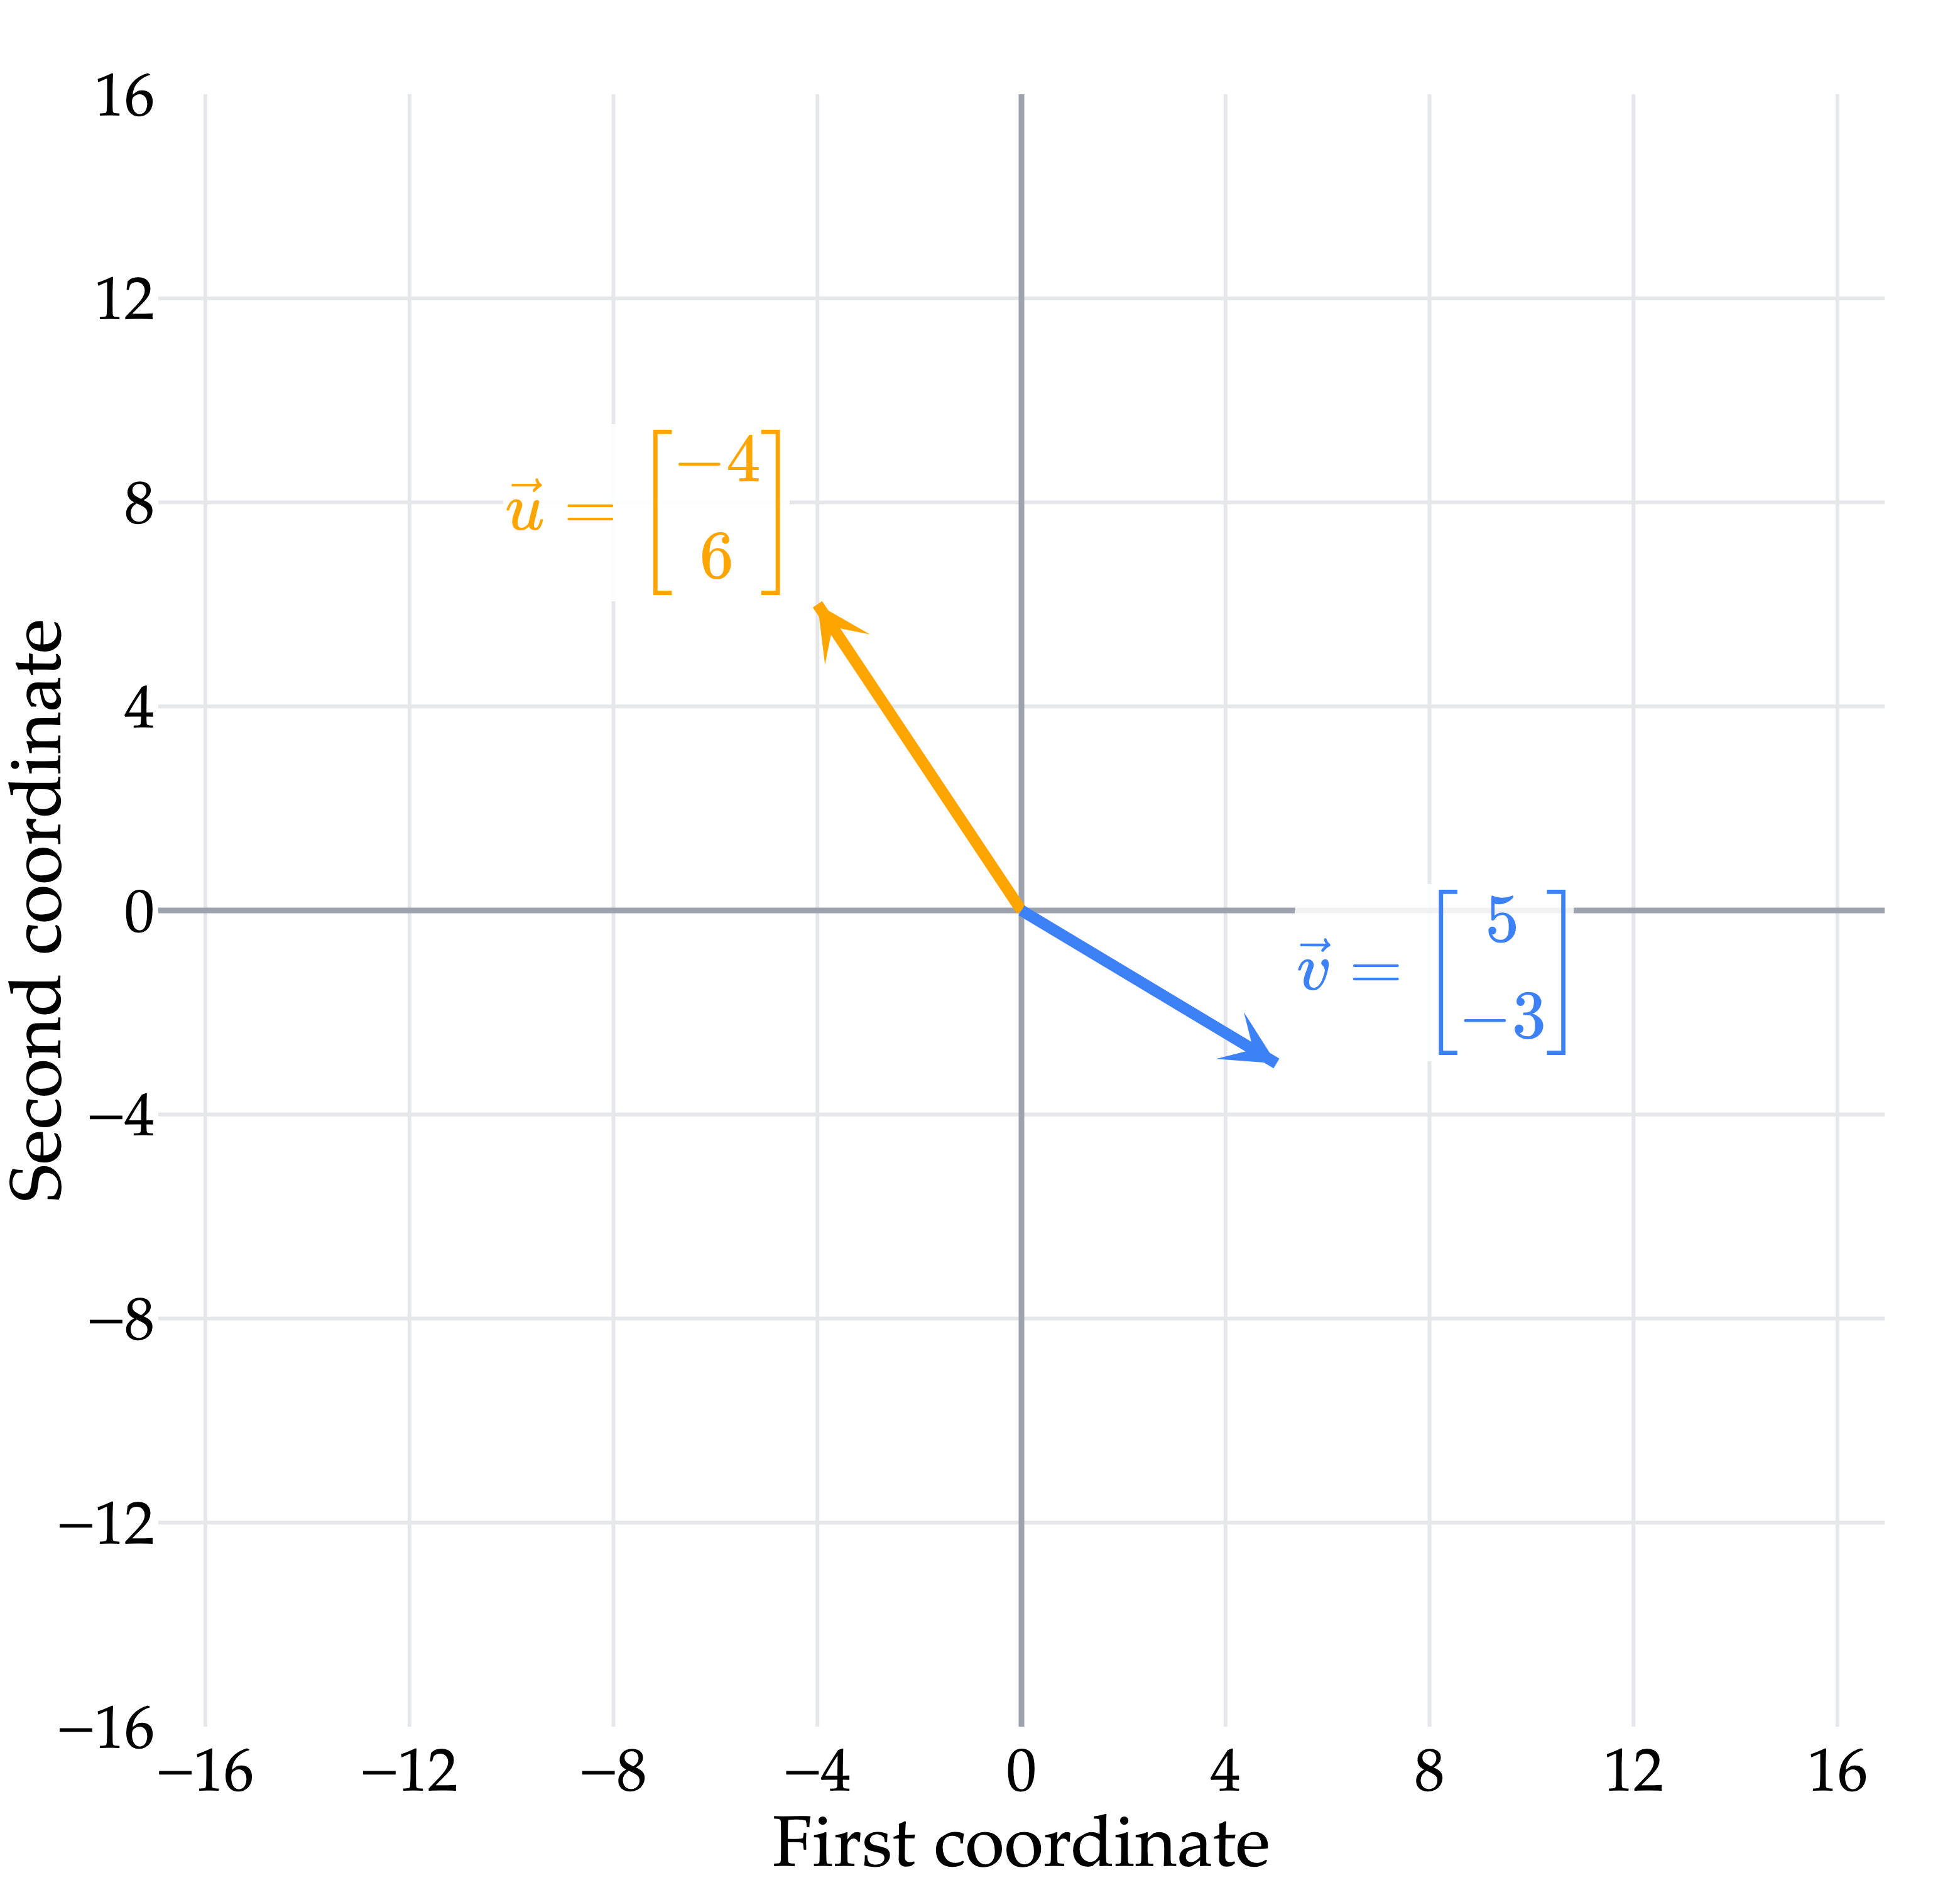
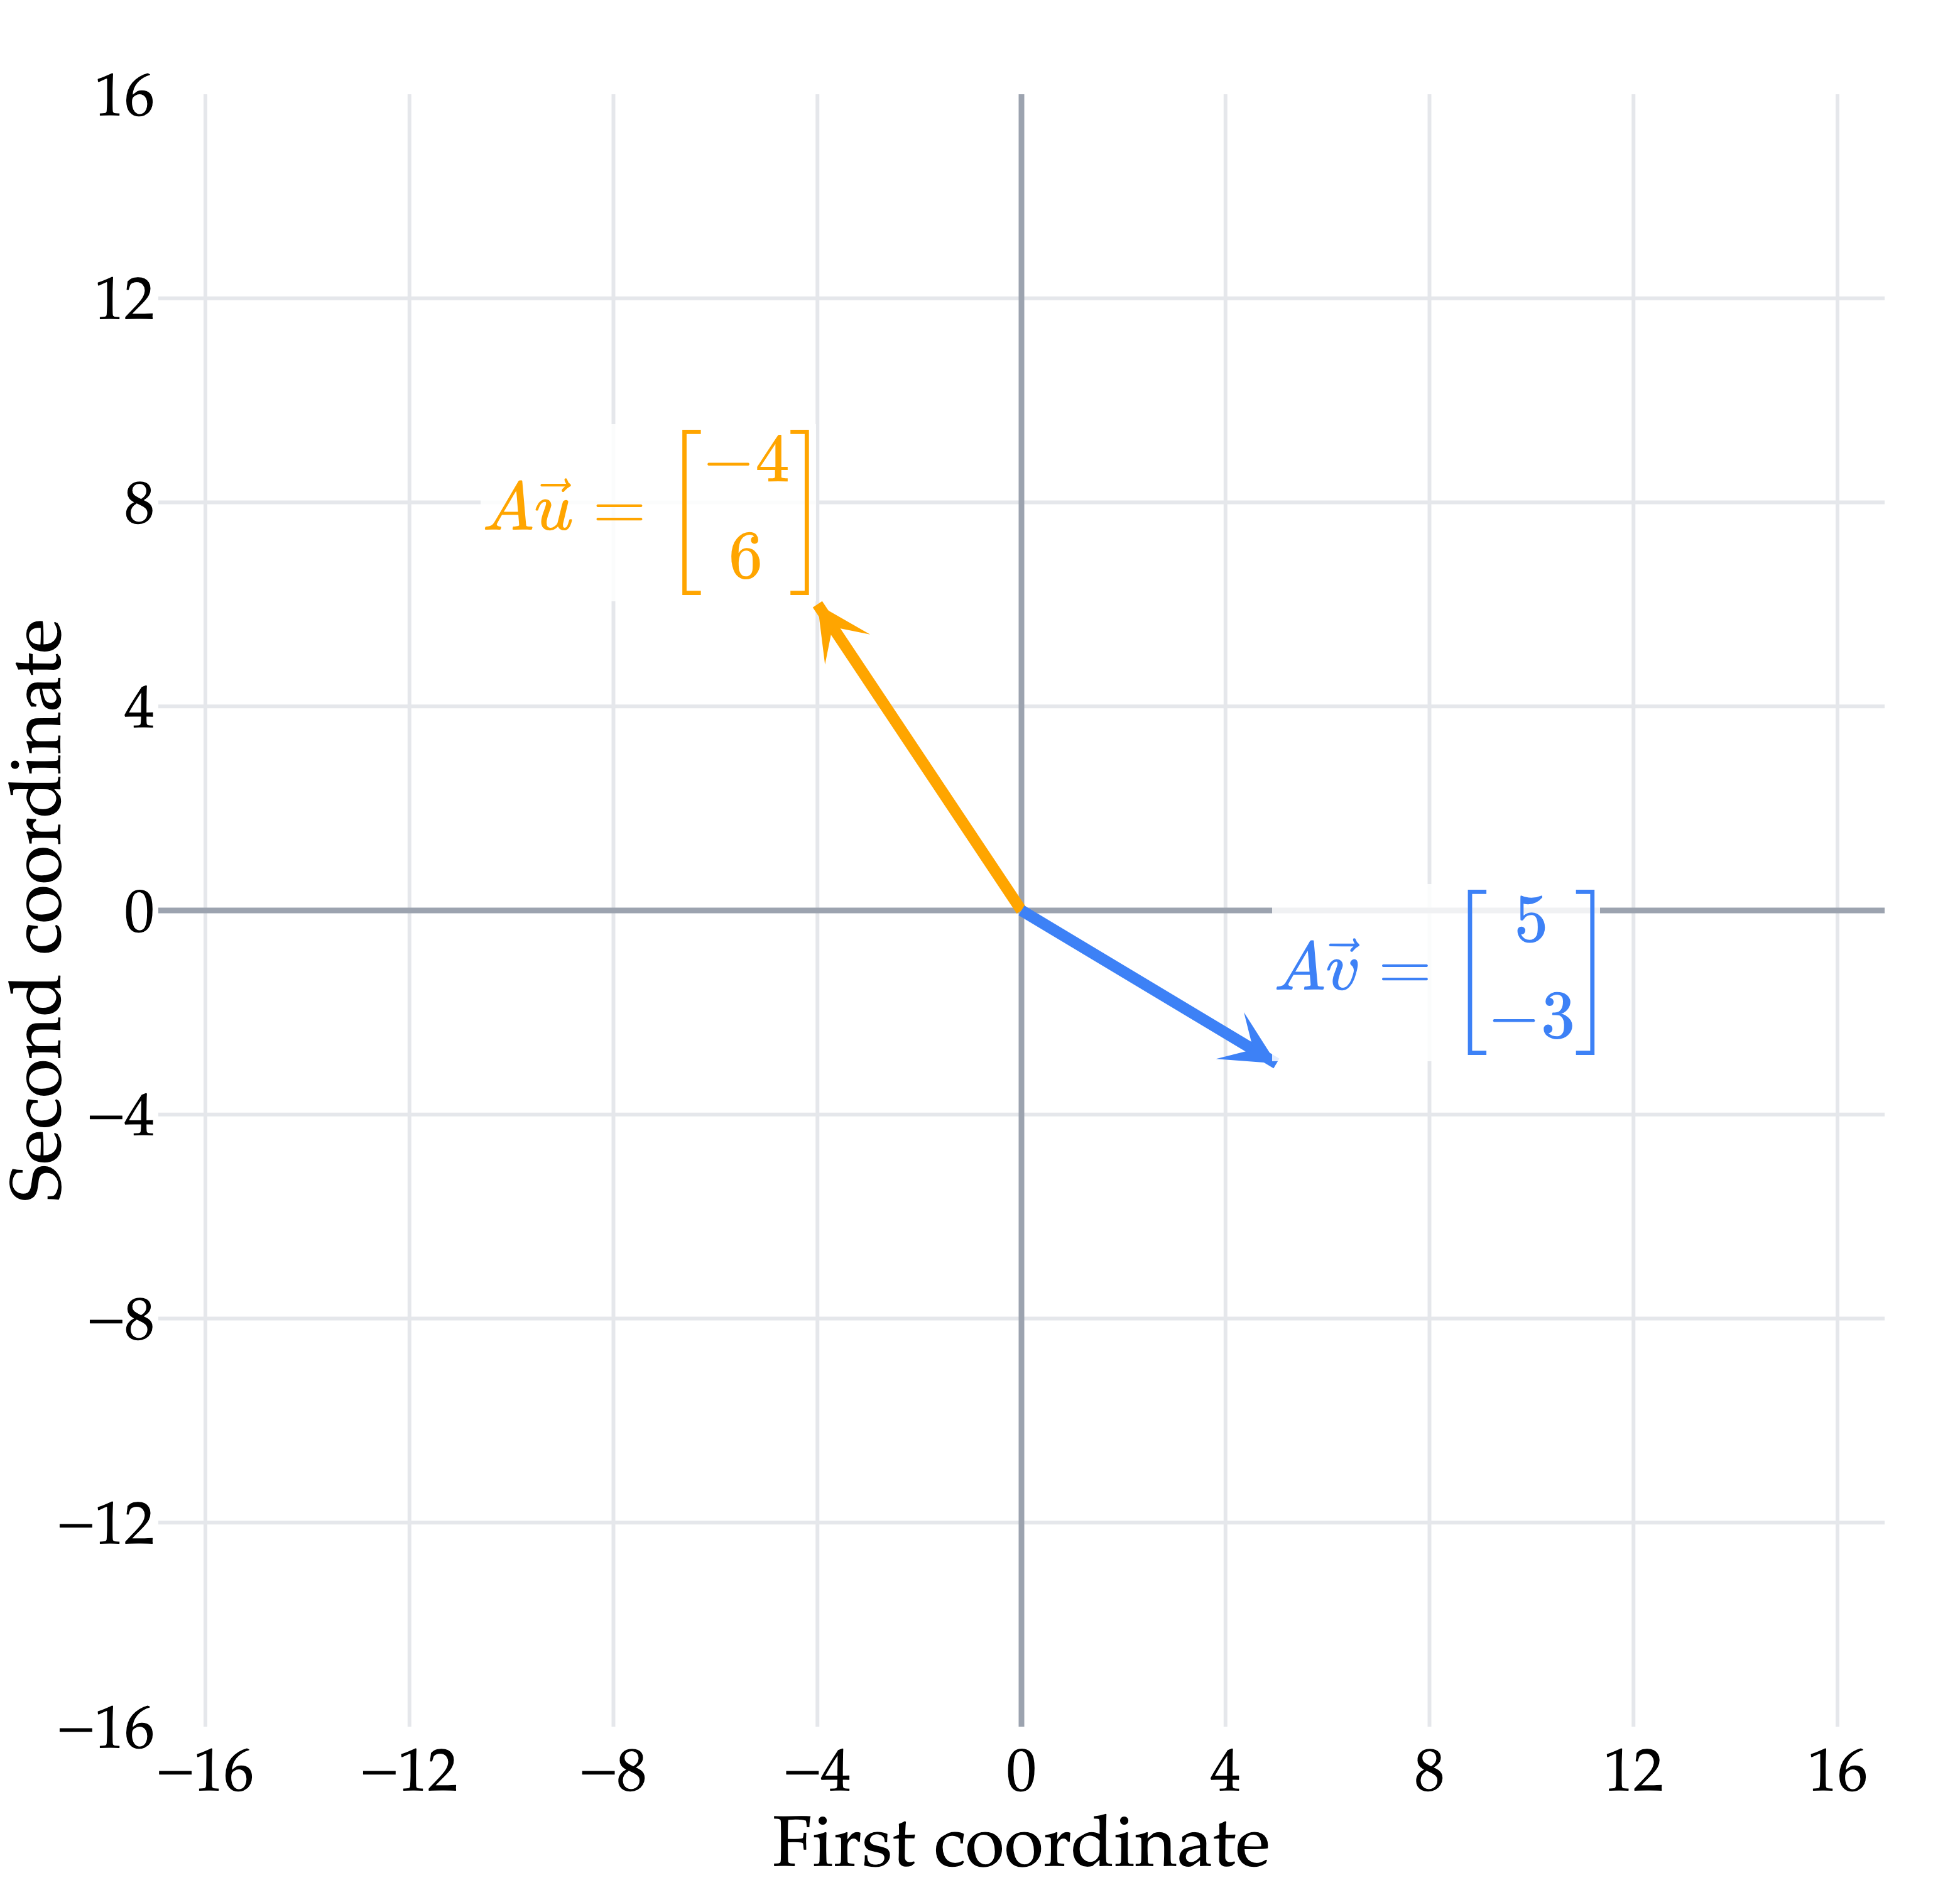

In [3]:
display_pair('transformation-identity.png', [[-4, 6], [5, -3]], [r'A\vec u',r'A\vec v'], limit=16)


This matrix leaves every vector unchanged.

$$A\begin{bmatrix}a\\b\end{bmatrix}=\begin{bmatrix}a\\b\end{bmatrix}.$$

:::{note} Definition
An **identity matrix** is a square matrix with ones on its main diagonal and zeros elsewhere. The $n\times n$ identity is written $I_n$, and $I_n\vec v=\vec v$ for every $\vec v\in\mathbb R^n$.
:::


### Example 2

$$A=\begin{bmatrix}-3/2&0\\0&2\end{bmatrix},\qquad\vec u=\begin{bmatrix}-4\\6\end{bmatrix},\qquad\vec v=\begin{bmatrix}5\\-3\end{bmatrix}.$$

:::{tip} Try it
:class: dropdown

1. Compute $A\vec u$ and $A\vec v$.
2. Draw the inputs and outputs on separate Before and After graphs.
3. Compute $A\begin{bmatrix}a\\b\end{bmatrix}$. Describe what the matrix does to every input.
:::



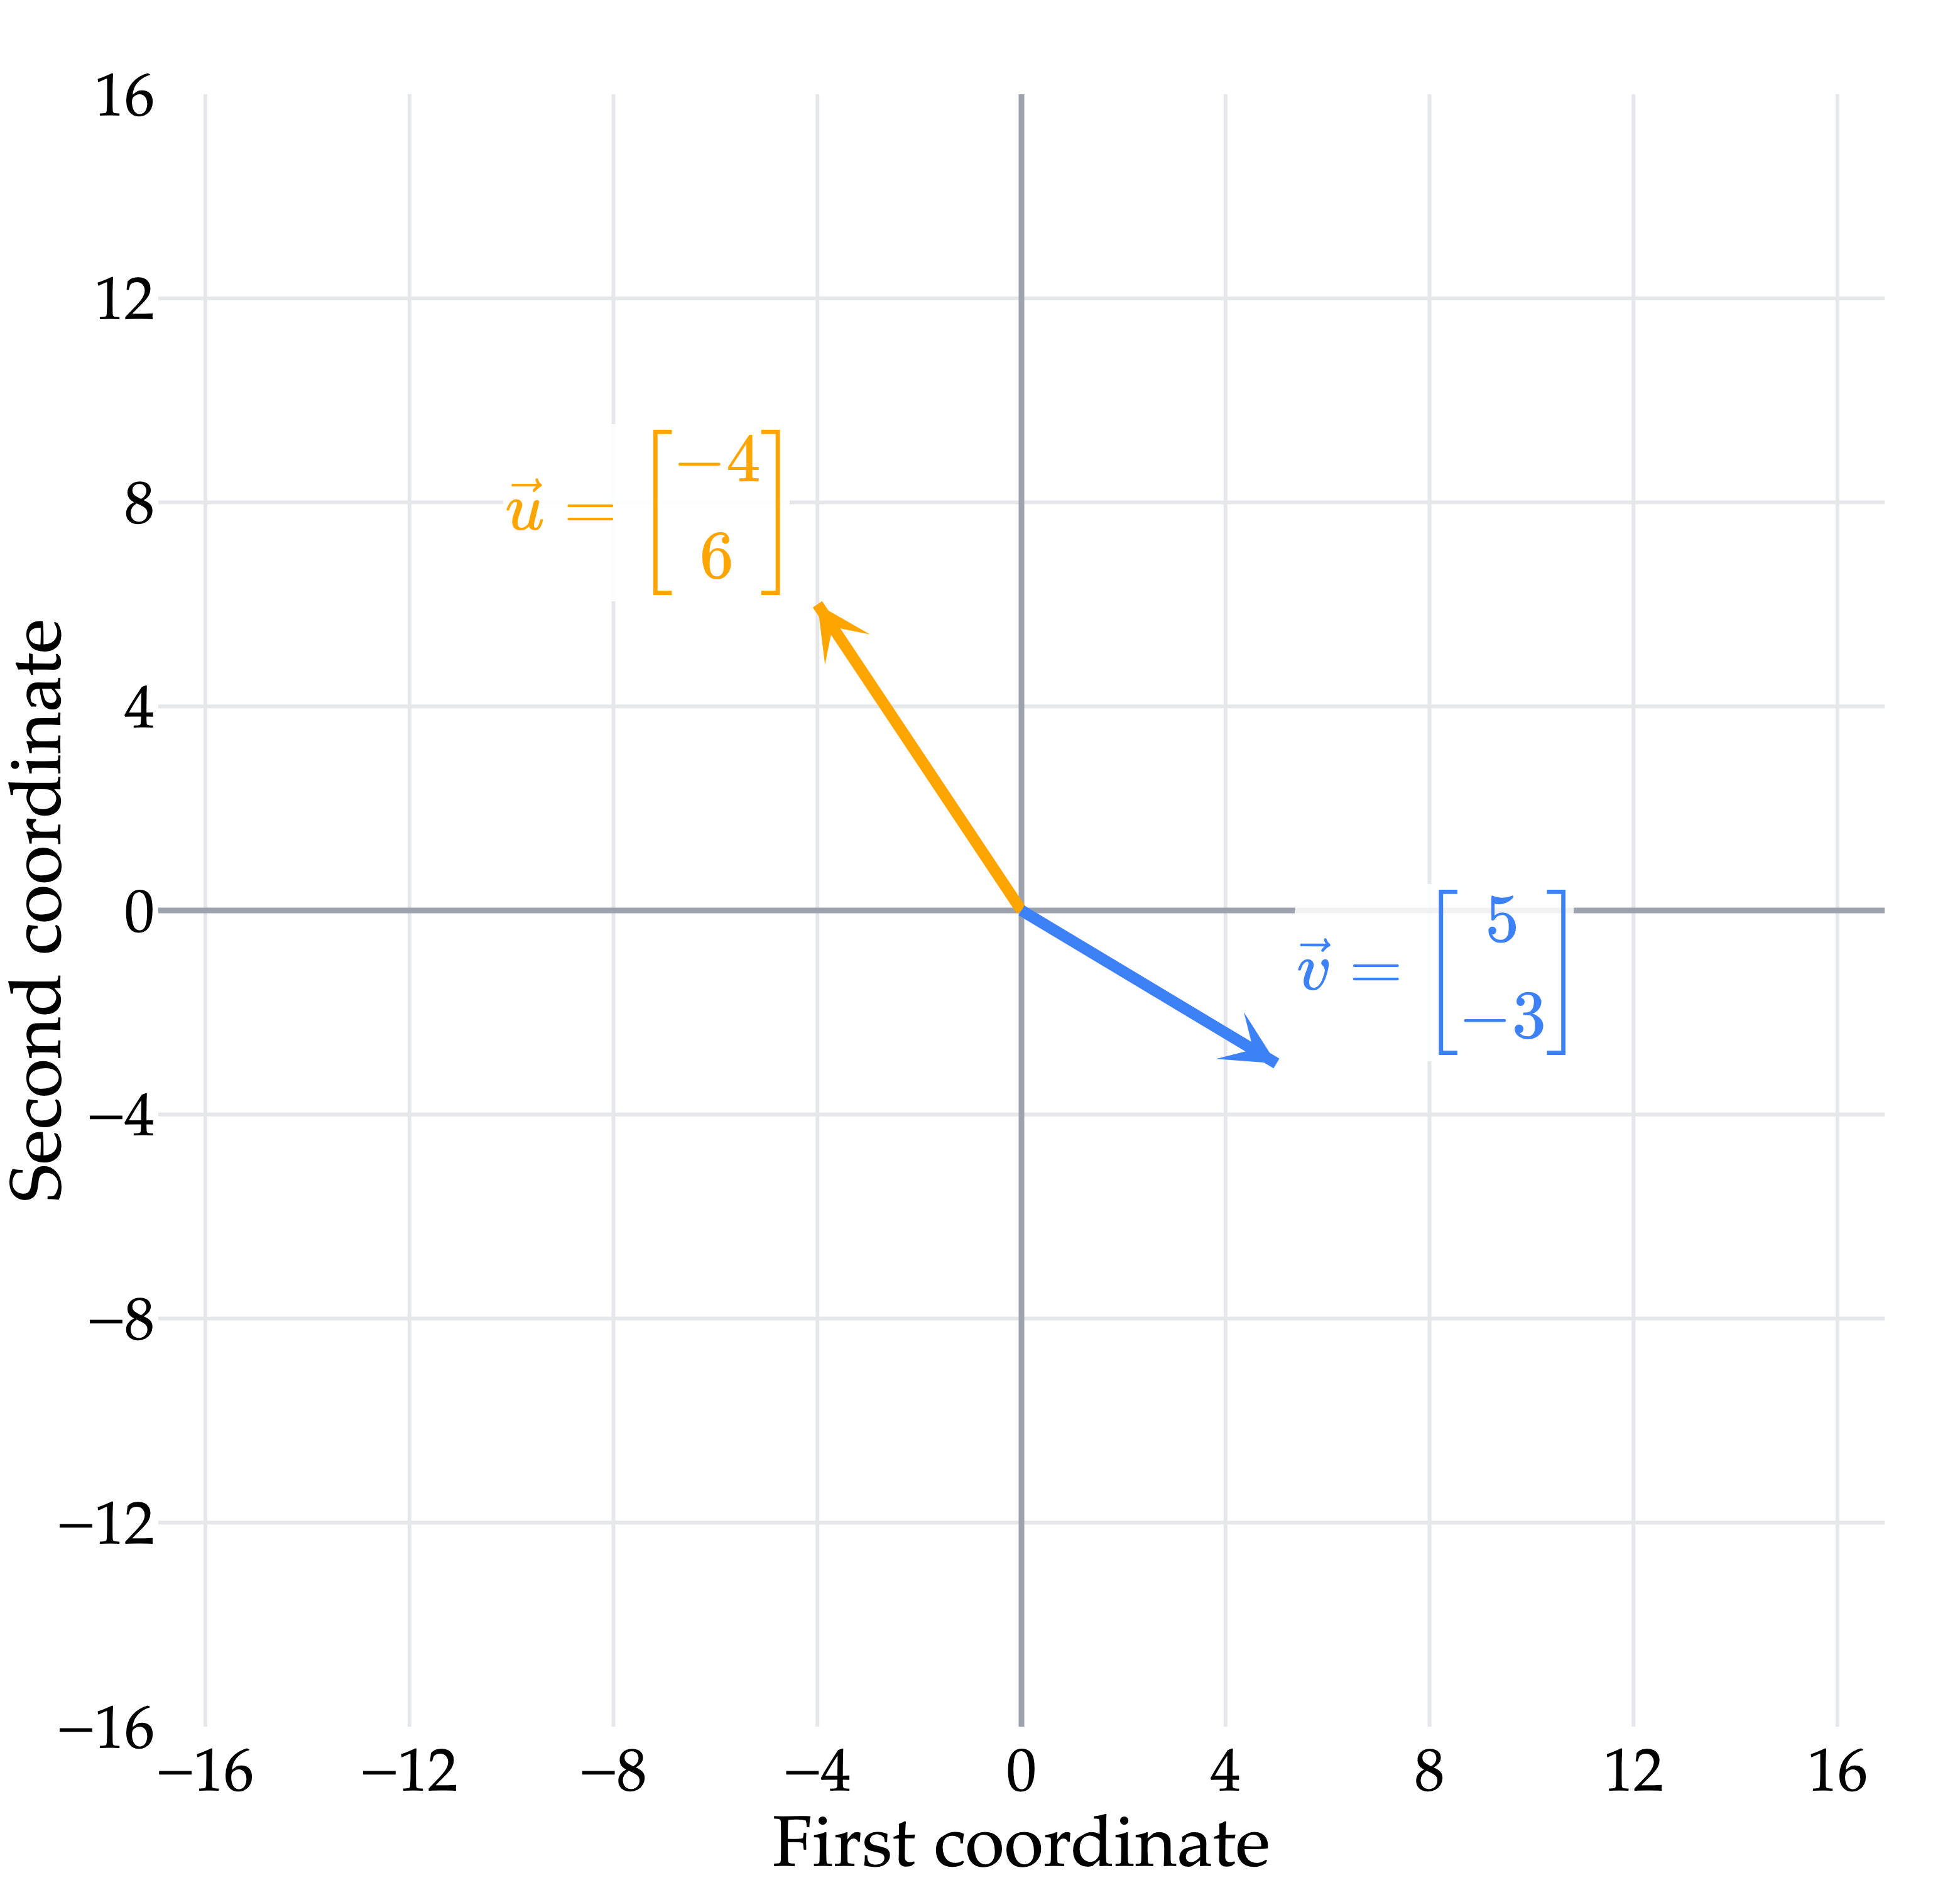
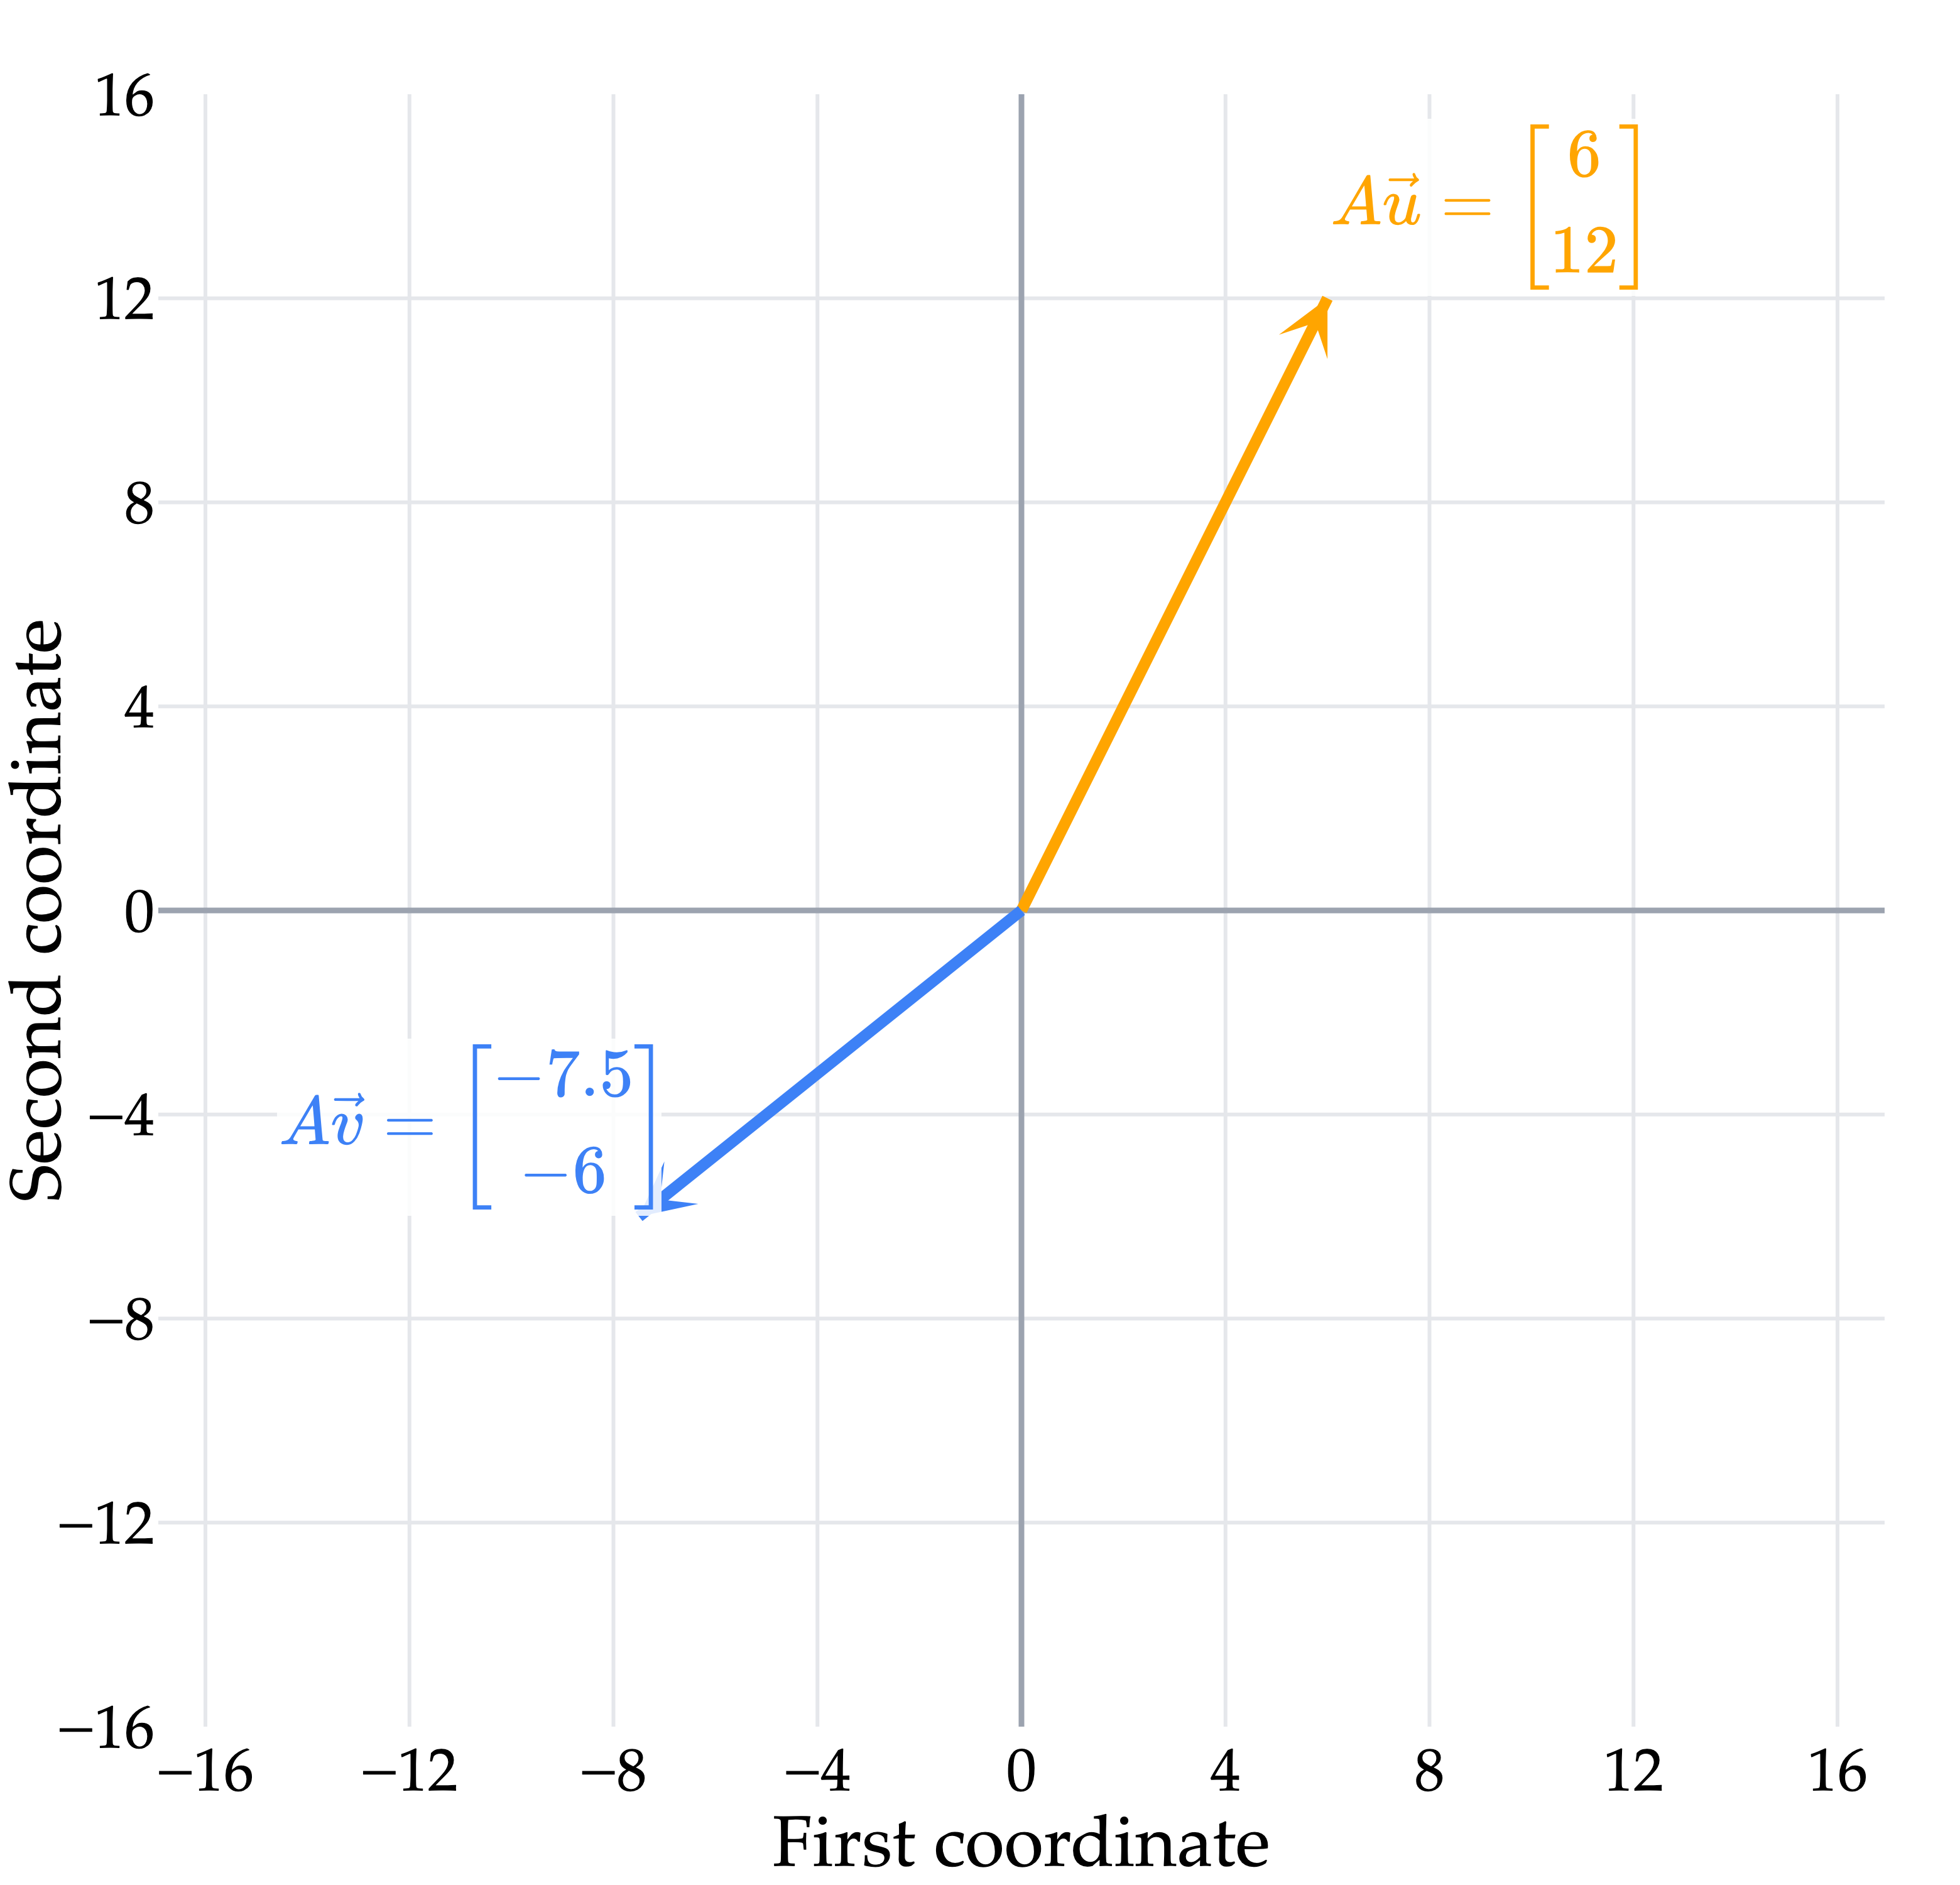

In [4]:
display_pair('transformation-diagonal.png', [[6, 12], [-7.5, -6]], [r'A\vec u',r'A\vec v'], limit=16)


This matrix multiplies the first coordinate by $-3/2$ and the second by $2$.

$$A\begin{bmatrix}a\\b\end{bmatrix}=\begin{bmatrix}-3a/2\\2b\end{bmatrix}.$$

:::{note} Definition
A **diagonal matrix** is a square matrix whose entries off the main diagonal are zero. Multiplication scales each coordinate by its corresponding diagonal entry. The identity is a diagonal matrix, too.
:::


### Example 3

$$A=\begin{bmatrix}0&1\\1&0\end{bmatrix},\qquad\vec u=\begin{bmatrix}-4\\6\end{bmatrix},\qquad\vec v=\begin{bmatrix}5\\-3\end{bmatrix}.$$

:::{tip} Try it
:class: dropdown

1. Compute $A\vec u$ and $A\vec v$.
2. Draw the inputs and outputs on separate Before and After graphs.
3. Compute $A\begin{bmatrix}a\\b\end{bmatrix}$. Describe what the matrix does to every input.
:::



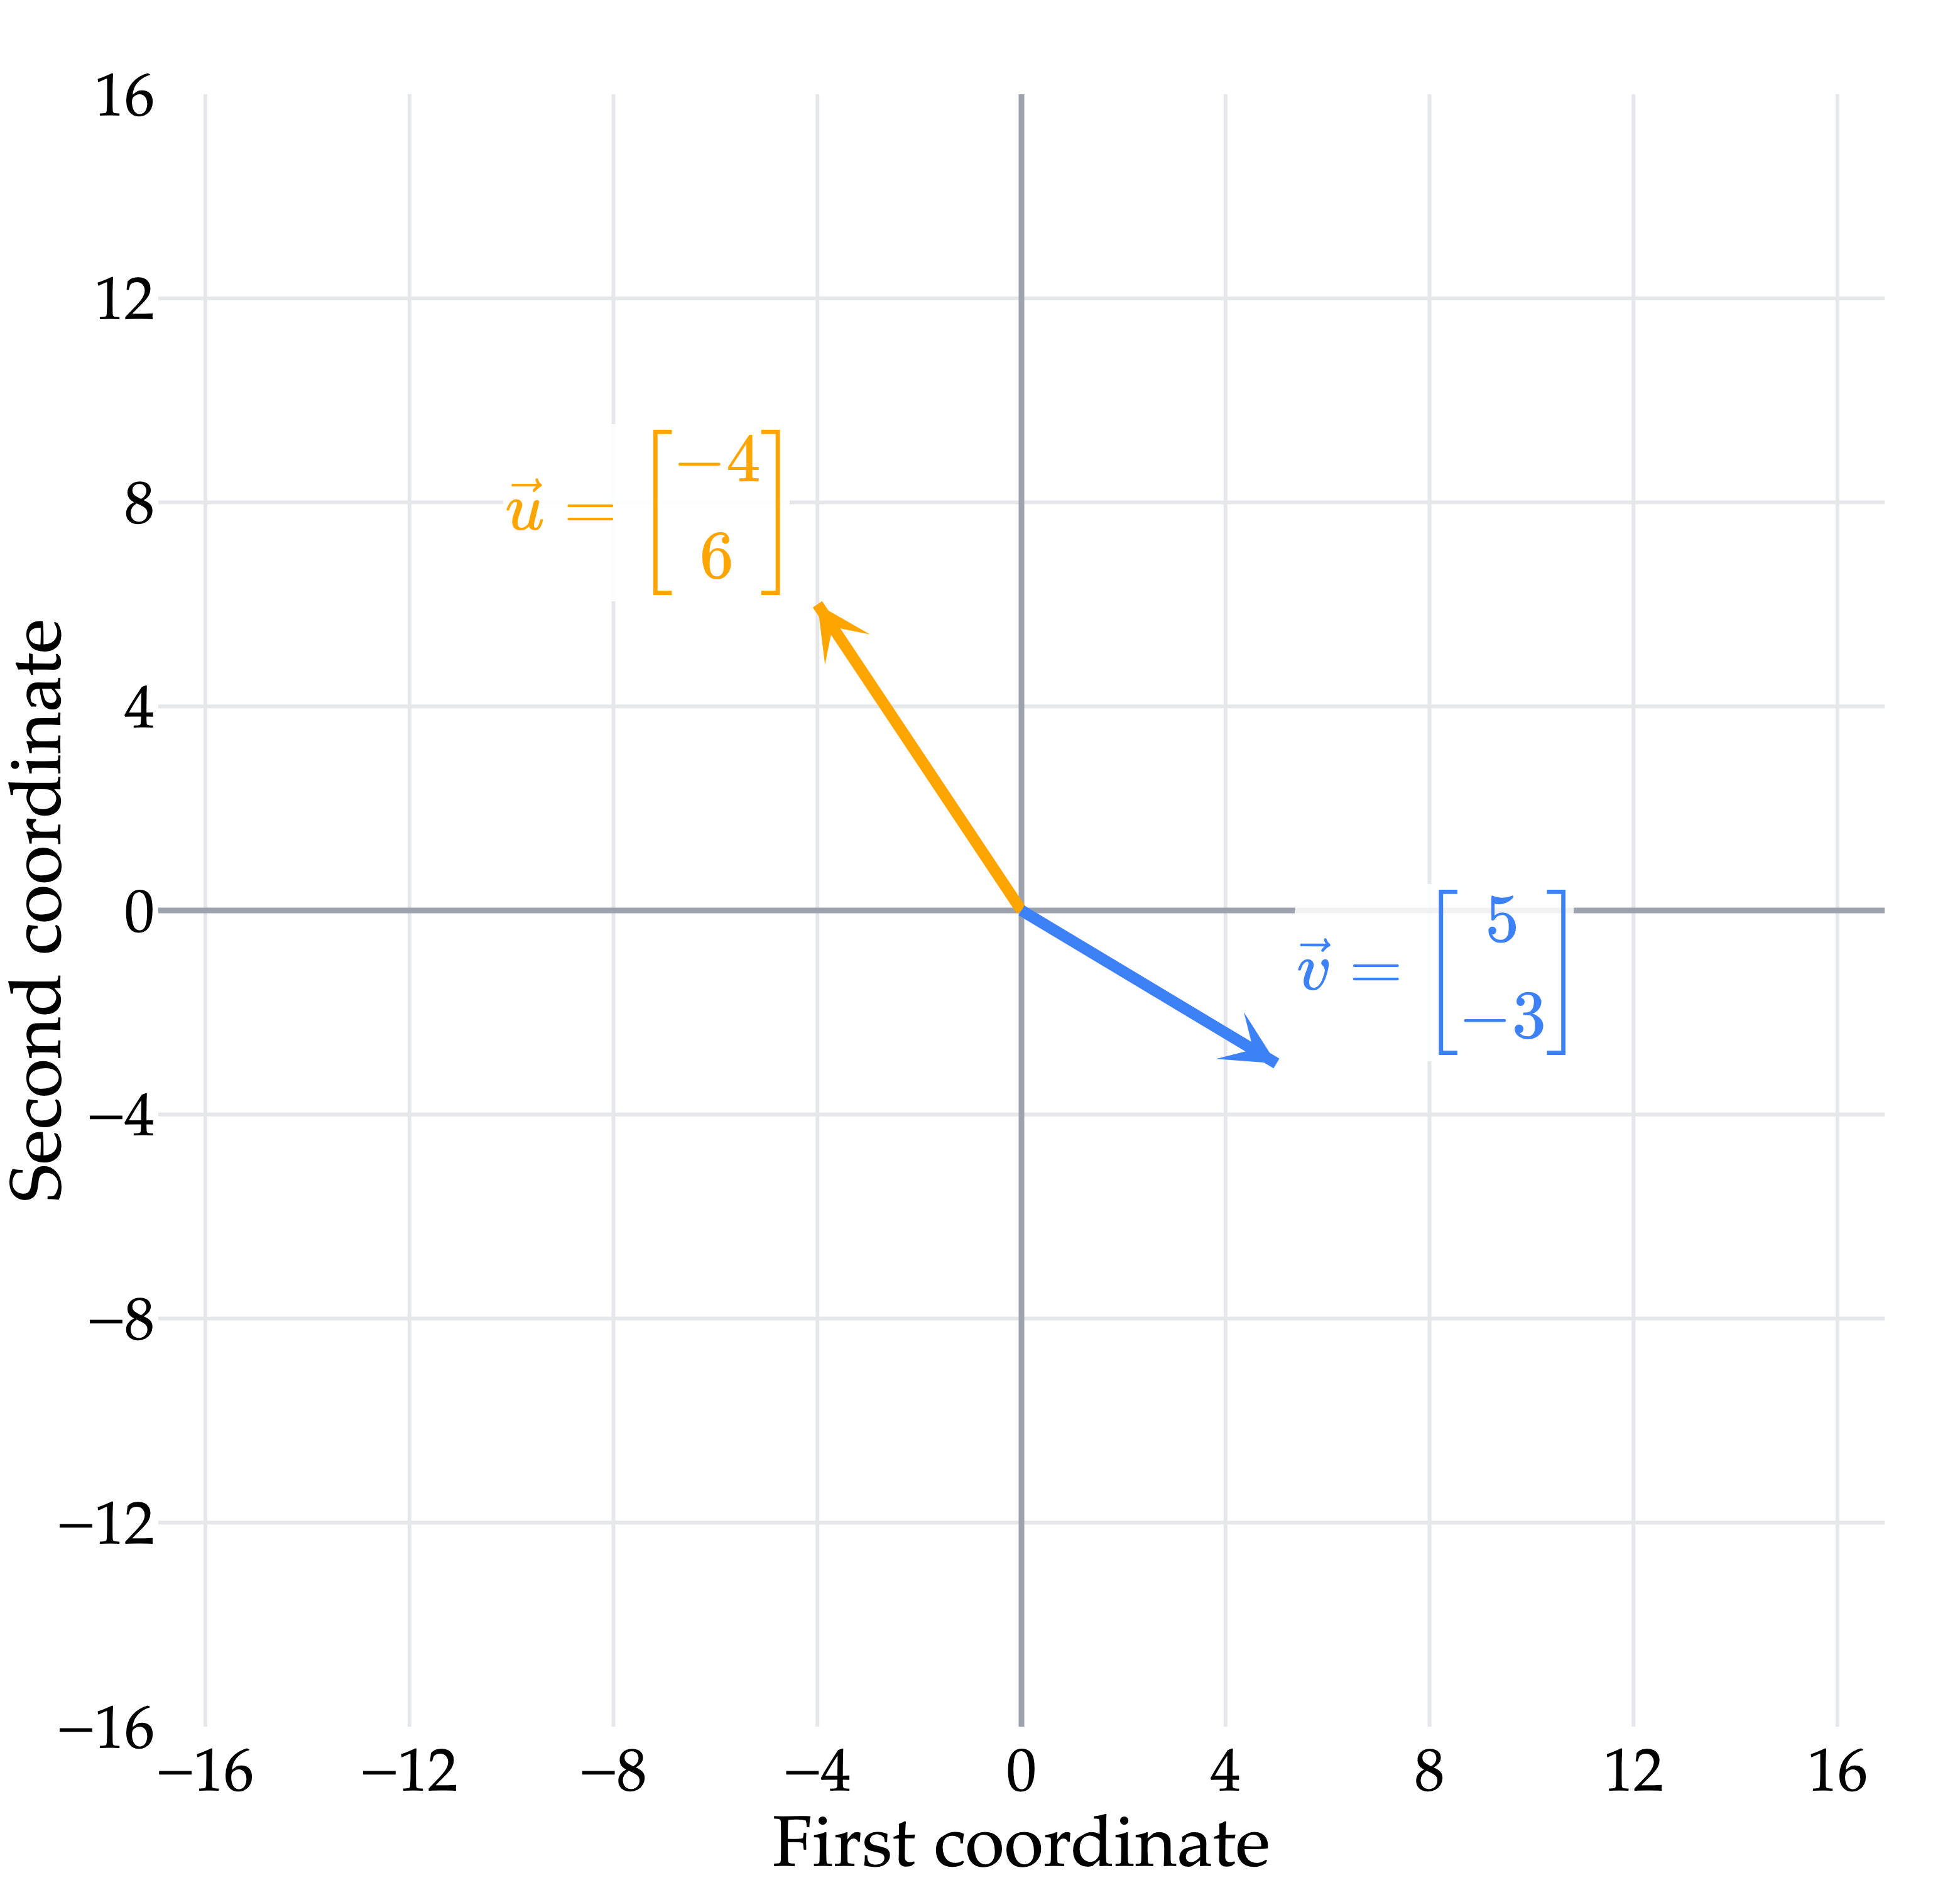
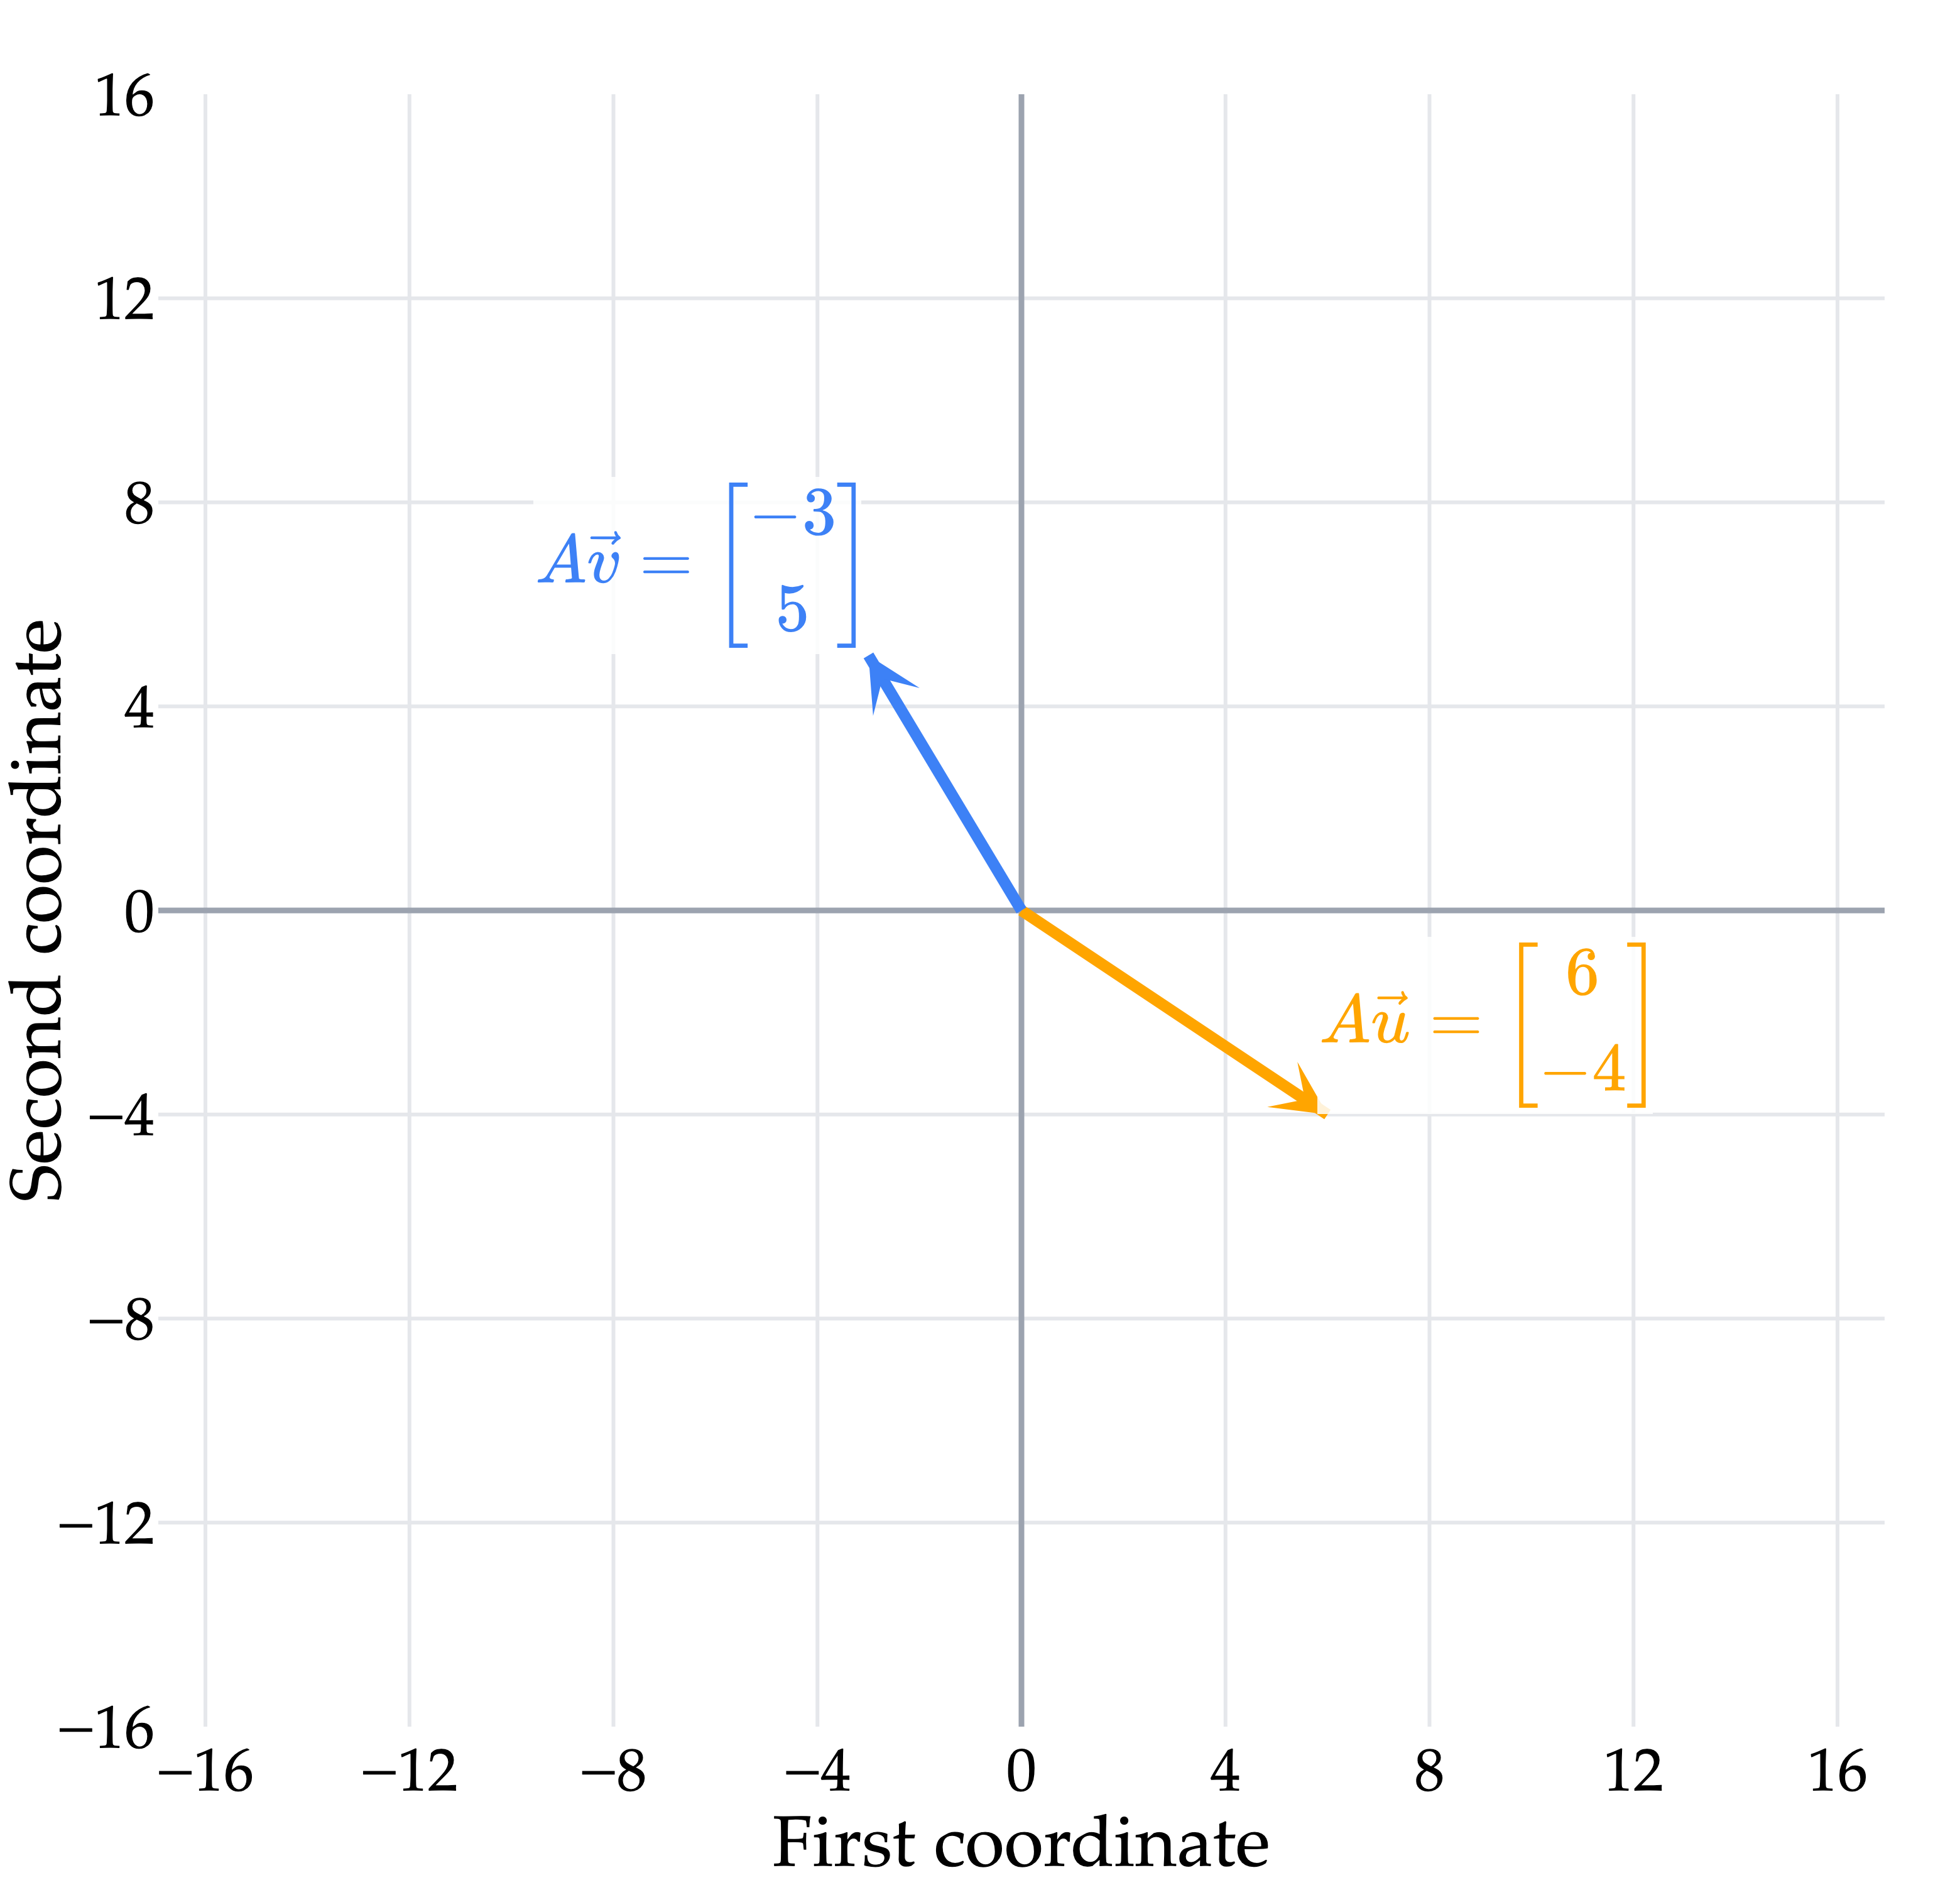

In [5]:
display_pair('transformation-permutation.png', [[6, -4], [-3, 5]], [r'A\vec u',r'A\vec v'], limit=16)


The two coordinates swap. Geometrically, this reflects vectors across the line with equation $x_2=x_1$.

$$A\begin{bmatrix}a\\b\end{bmatrix}=\begin{bmatrix}b\\a\end{bmatrix}.$$

:::{note} Definition
A **permutation matrix** is a square matrix with exactly one $1$ in every row and every column, and zeros elsewhere. Multiplication reorders the input entries.
:::


### Example 4

$$A=\begin{bmatrix}3&6\\-2&-4\end{bmatrix},\qquad\vec u=\begin{bmatrix}-4\\6\end{bmatrix},\qquad\vec v=\begin{bmatrix}5\\-3\end{bmatrix}.$$

:::{tip} Try it
:class: dropdown

1. Compute $A\vec u$ and $A\vec v$.
2. Draw the inputs and outputs on separate Before and After graphs.
3. Compute $A\begin{bmatrix}a\\b\end{bmatrix}$. Describe what the matrix does to every input.
:::



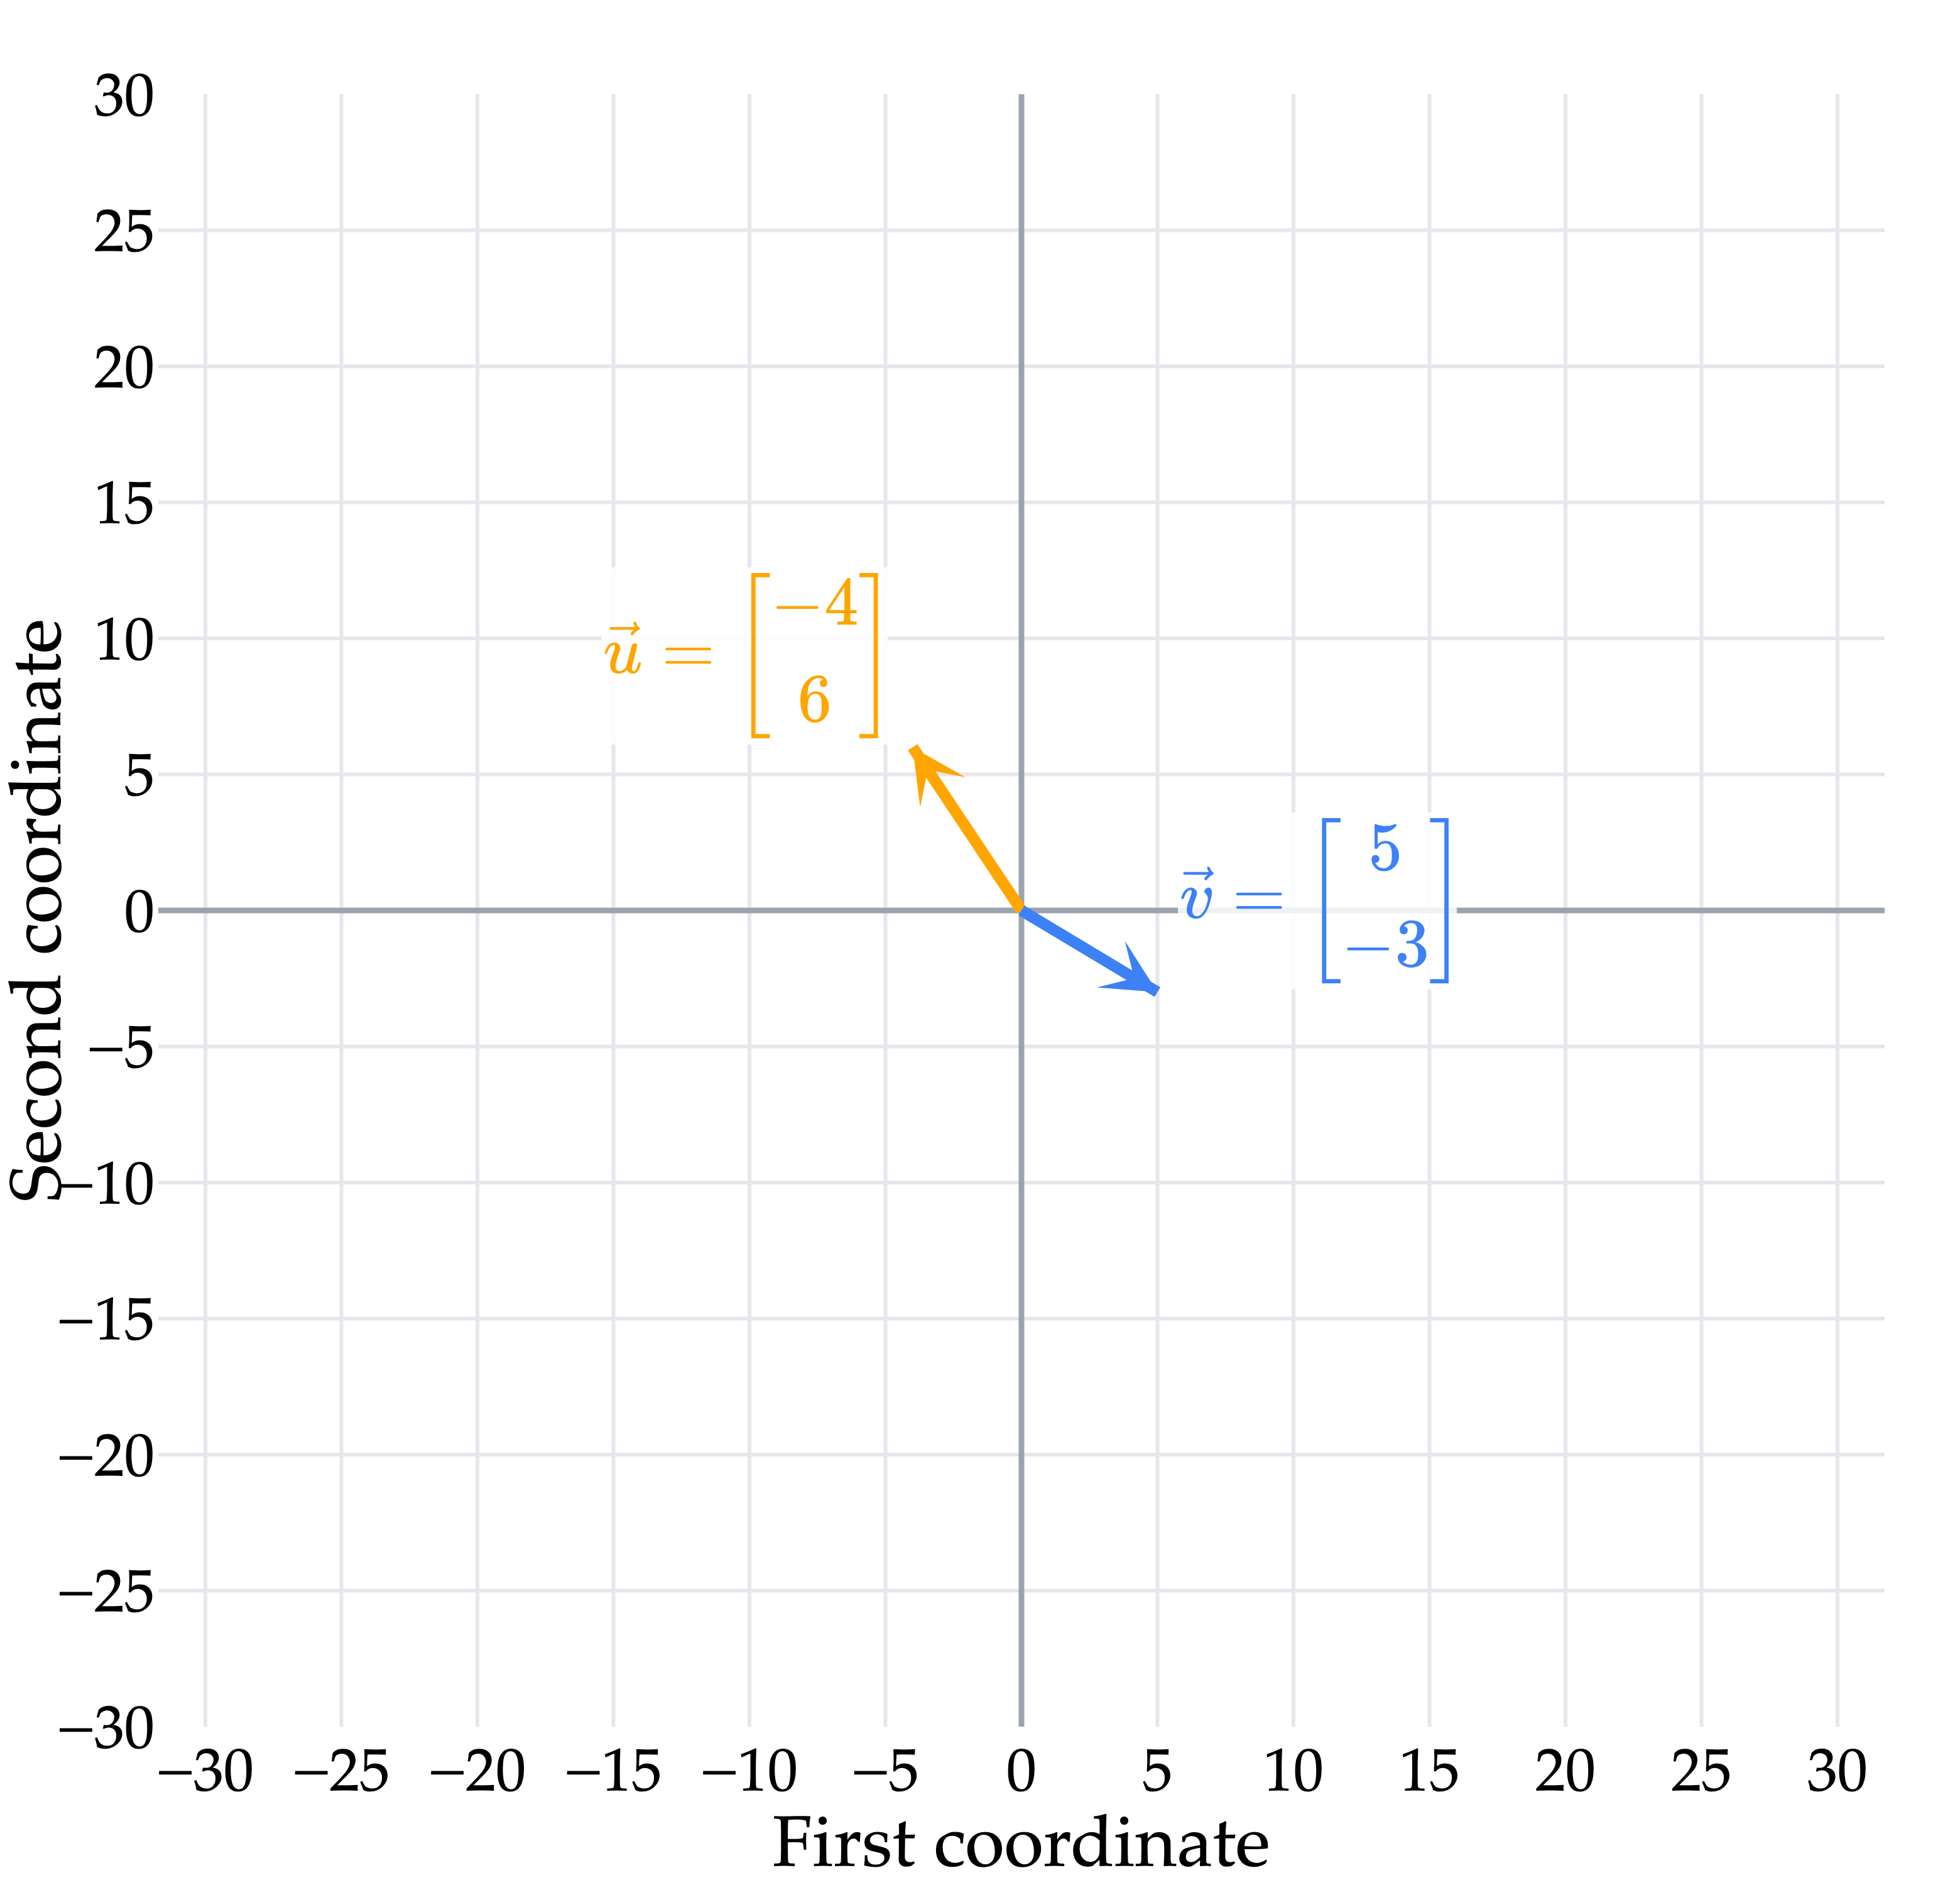
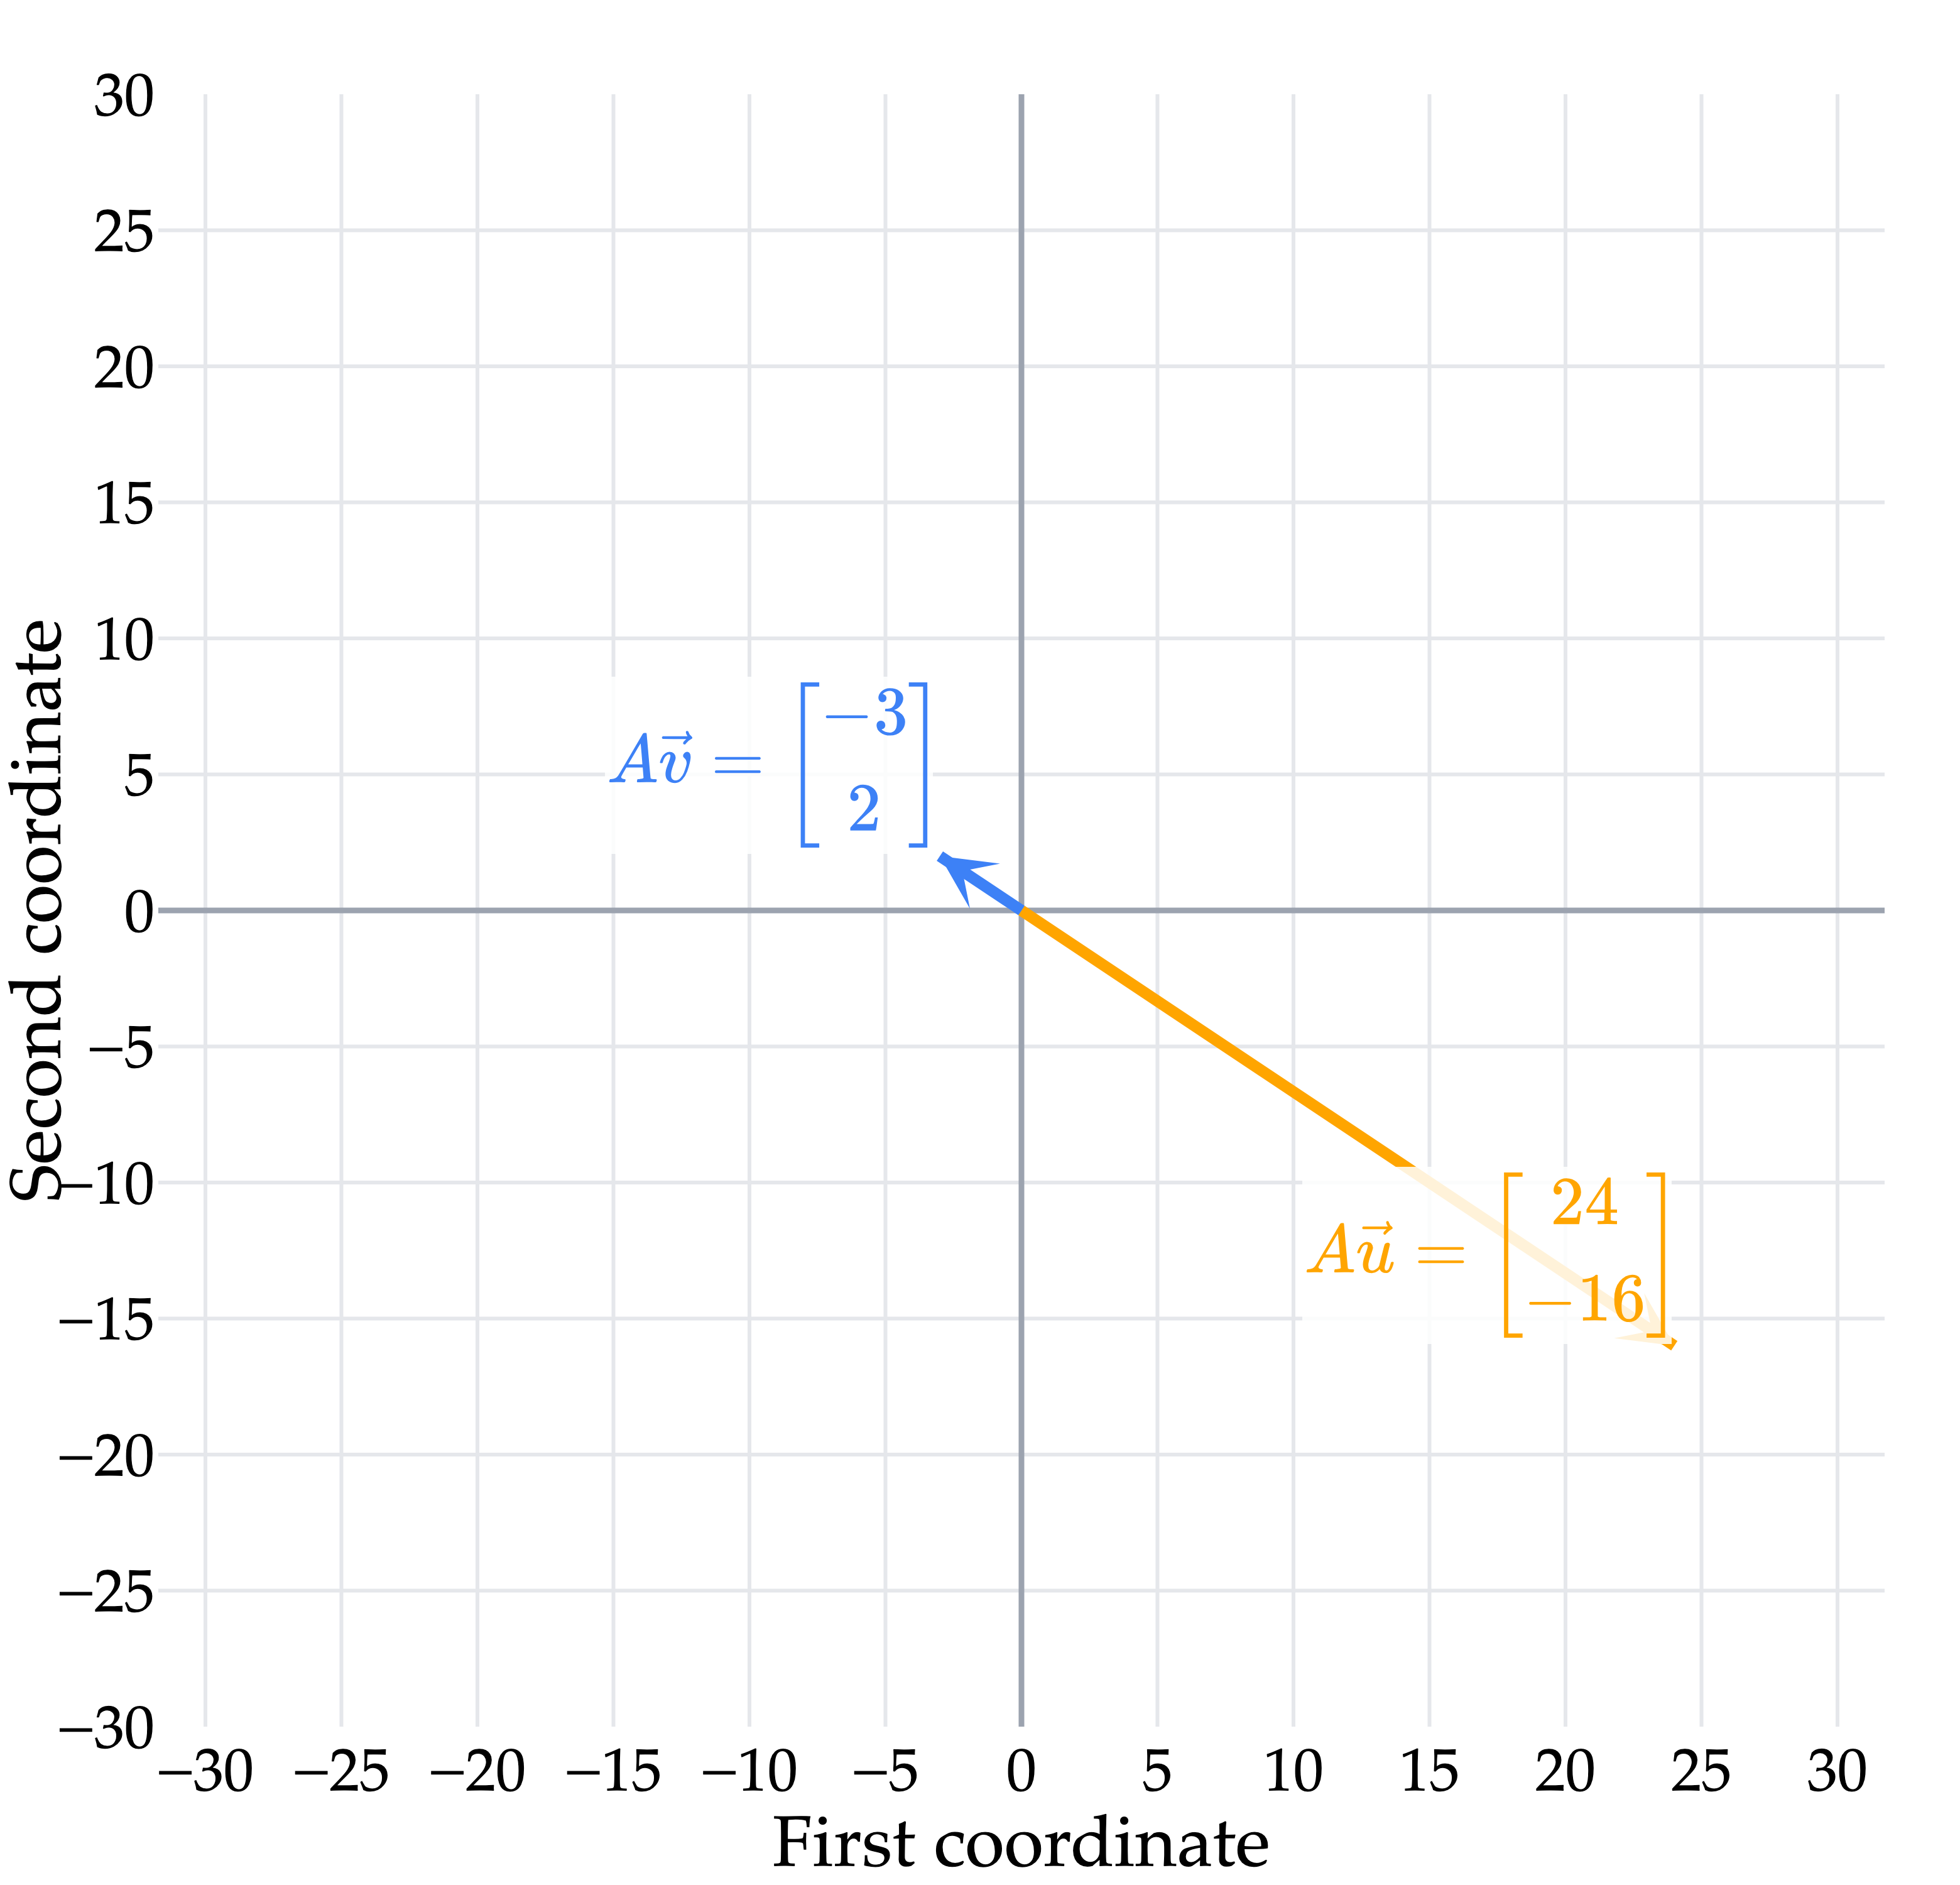

In [6]:
display_pair('transformation-rank-one.png', [[24, -16], [-3, 2]], [r'A\vec u',r'A\vec v'], limit=30)


Both outputs lie on the same line through the origin. Every output is a multiple of $\begin{bmatrix}3\\-2\end{bmatrix}$.

$$A\begin{bmatrix}a\\b\end{bmatrix}=\begin{bmatrix}3a+6b\\-2a-4b\end{bmatrix}=(a+2b)\begin{bmatrix}3\\-2\end{bmatrix}.$$


### Example 5

$$A=\begin{bmatrix}3/5&-4/5\\4/5&3/5\end{bmatrix},\qquad\vec u=\begin{bmatrix}-4\\6\end{bmatrix},\qquad\vec v=\begin{bmatrix}5\\-3\end{bmatrix}.$$

:::{tip} Try it
:class: dropdown

1. Compute $A\vec u$ and $A\vec v$.
2. Draw the inputs and outputs on separate Before and After graphs.
3. Compute $A\begin{bmatrix}a\\b\end{bmatrix}$. Describe what the matrix does to every input.
:::



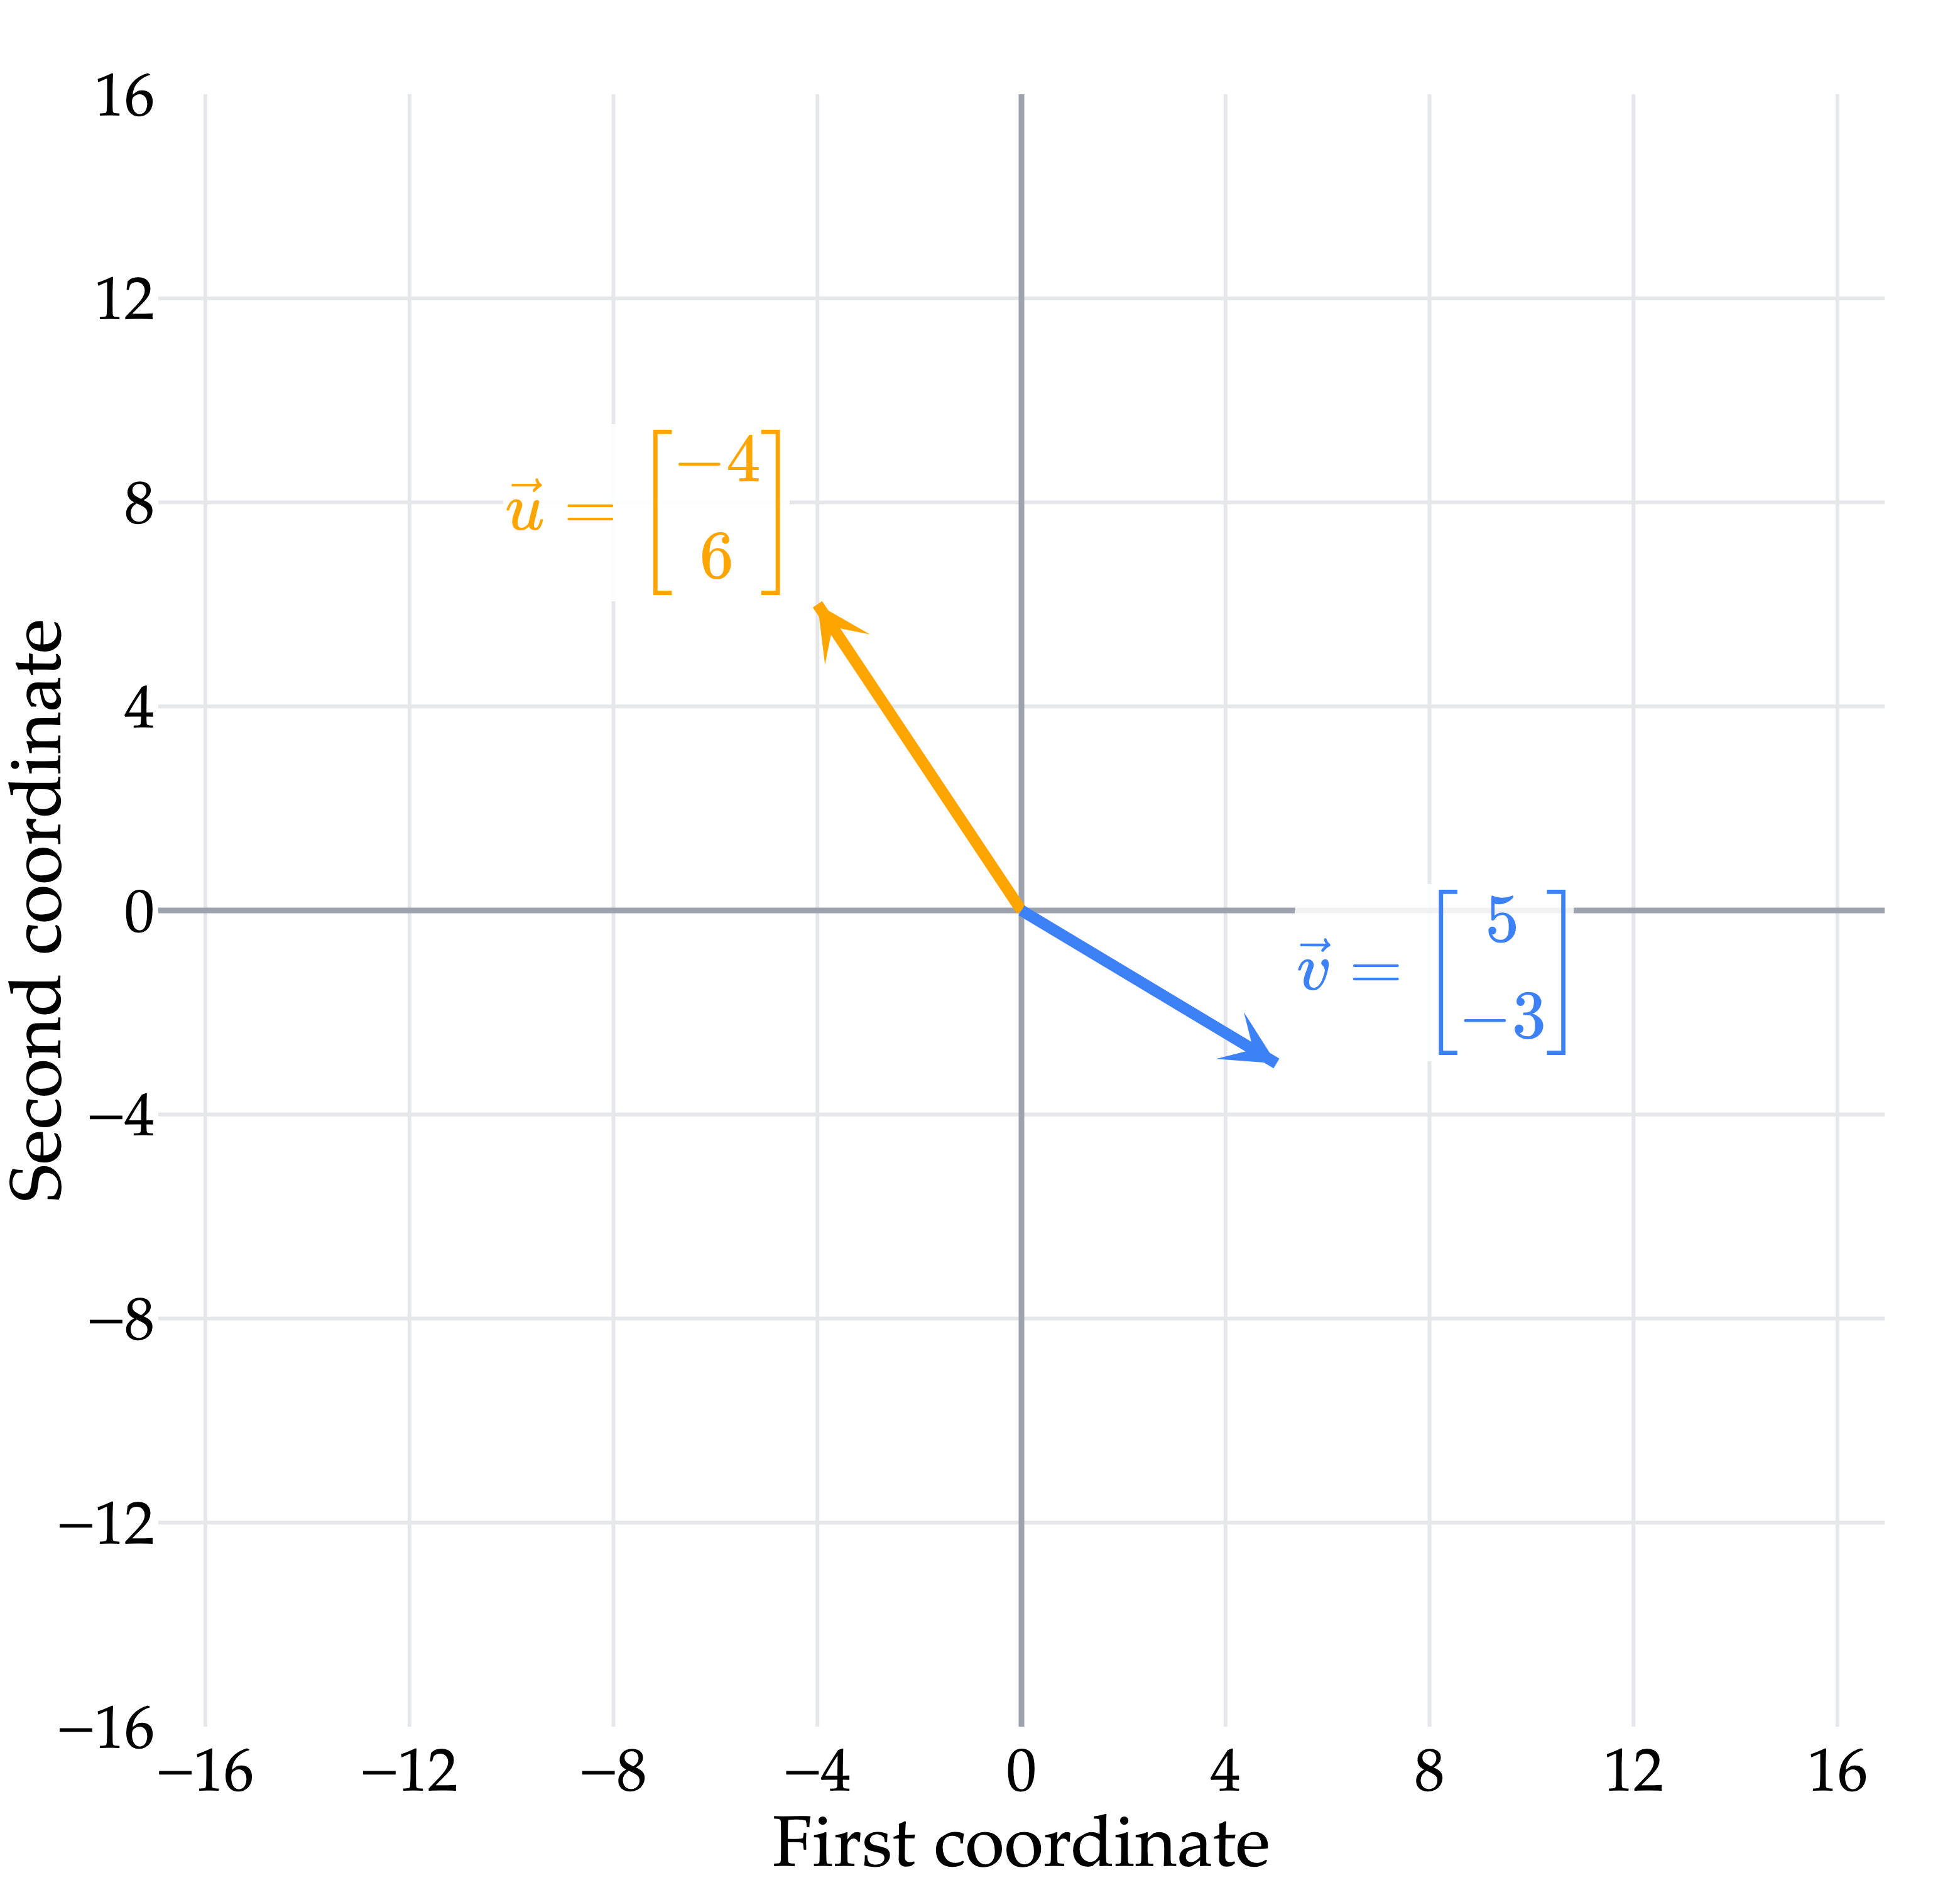
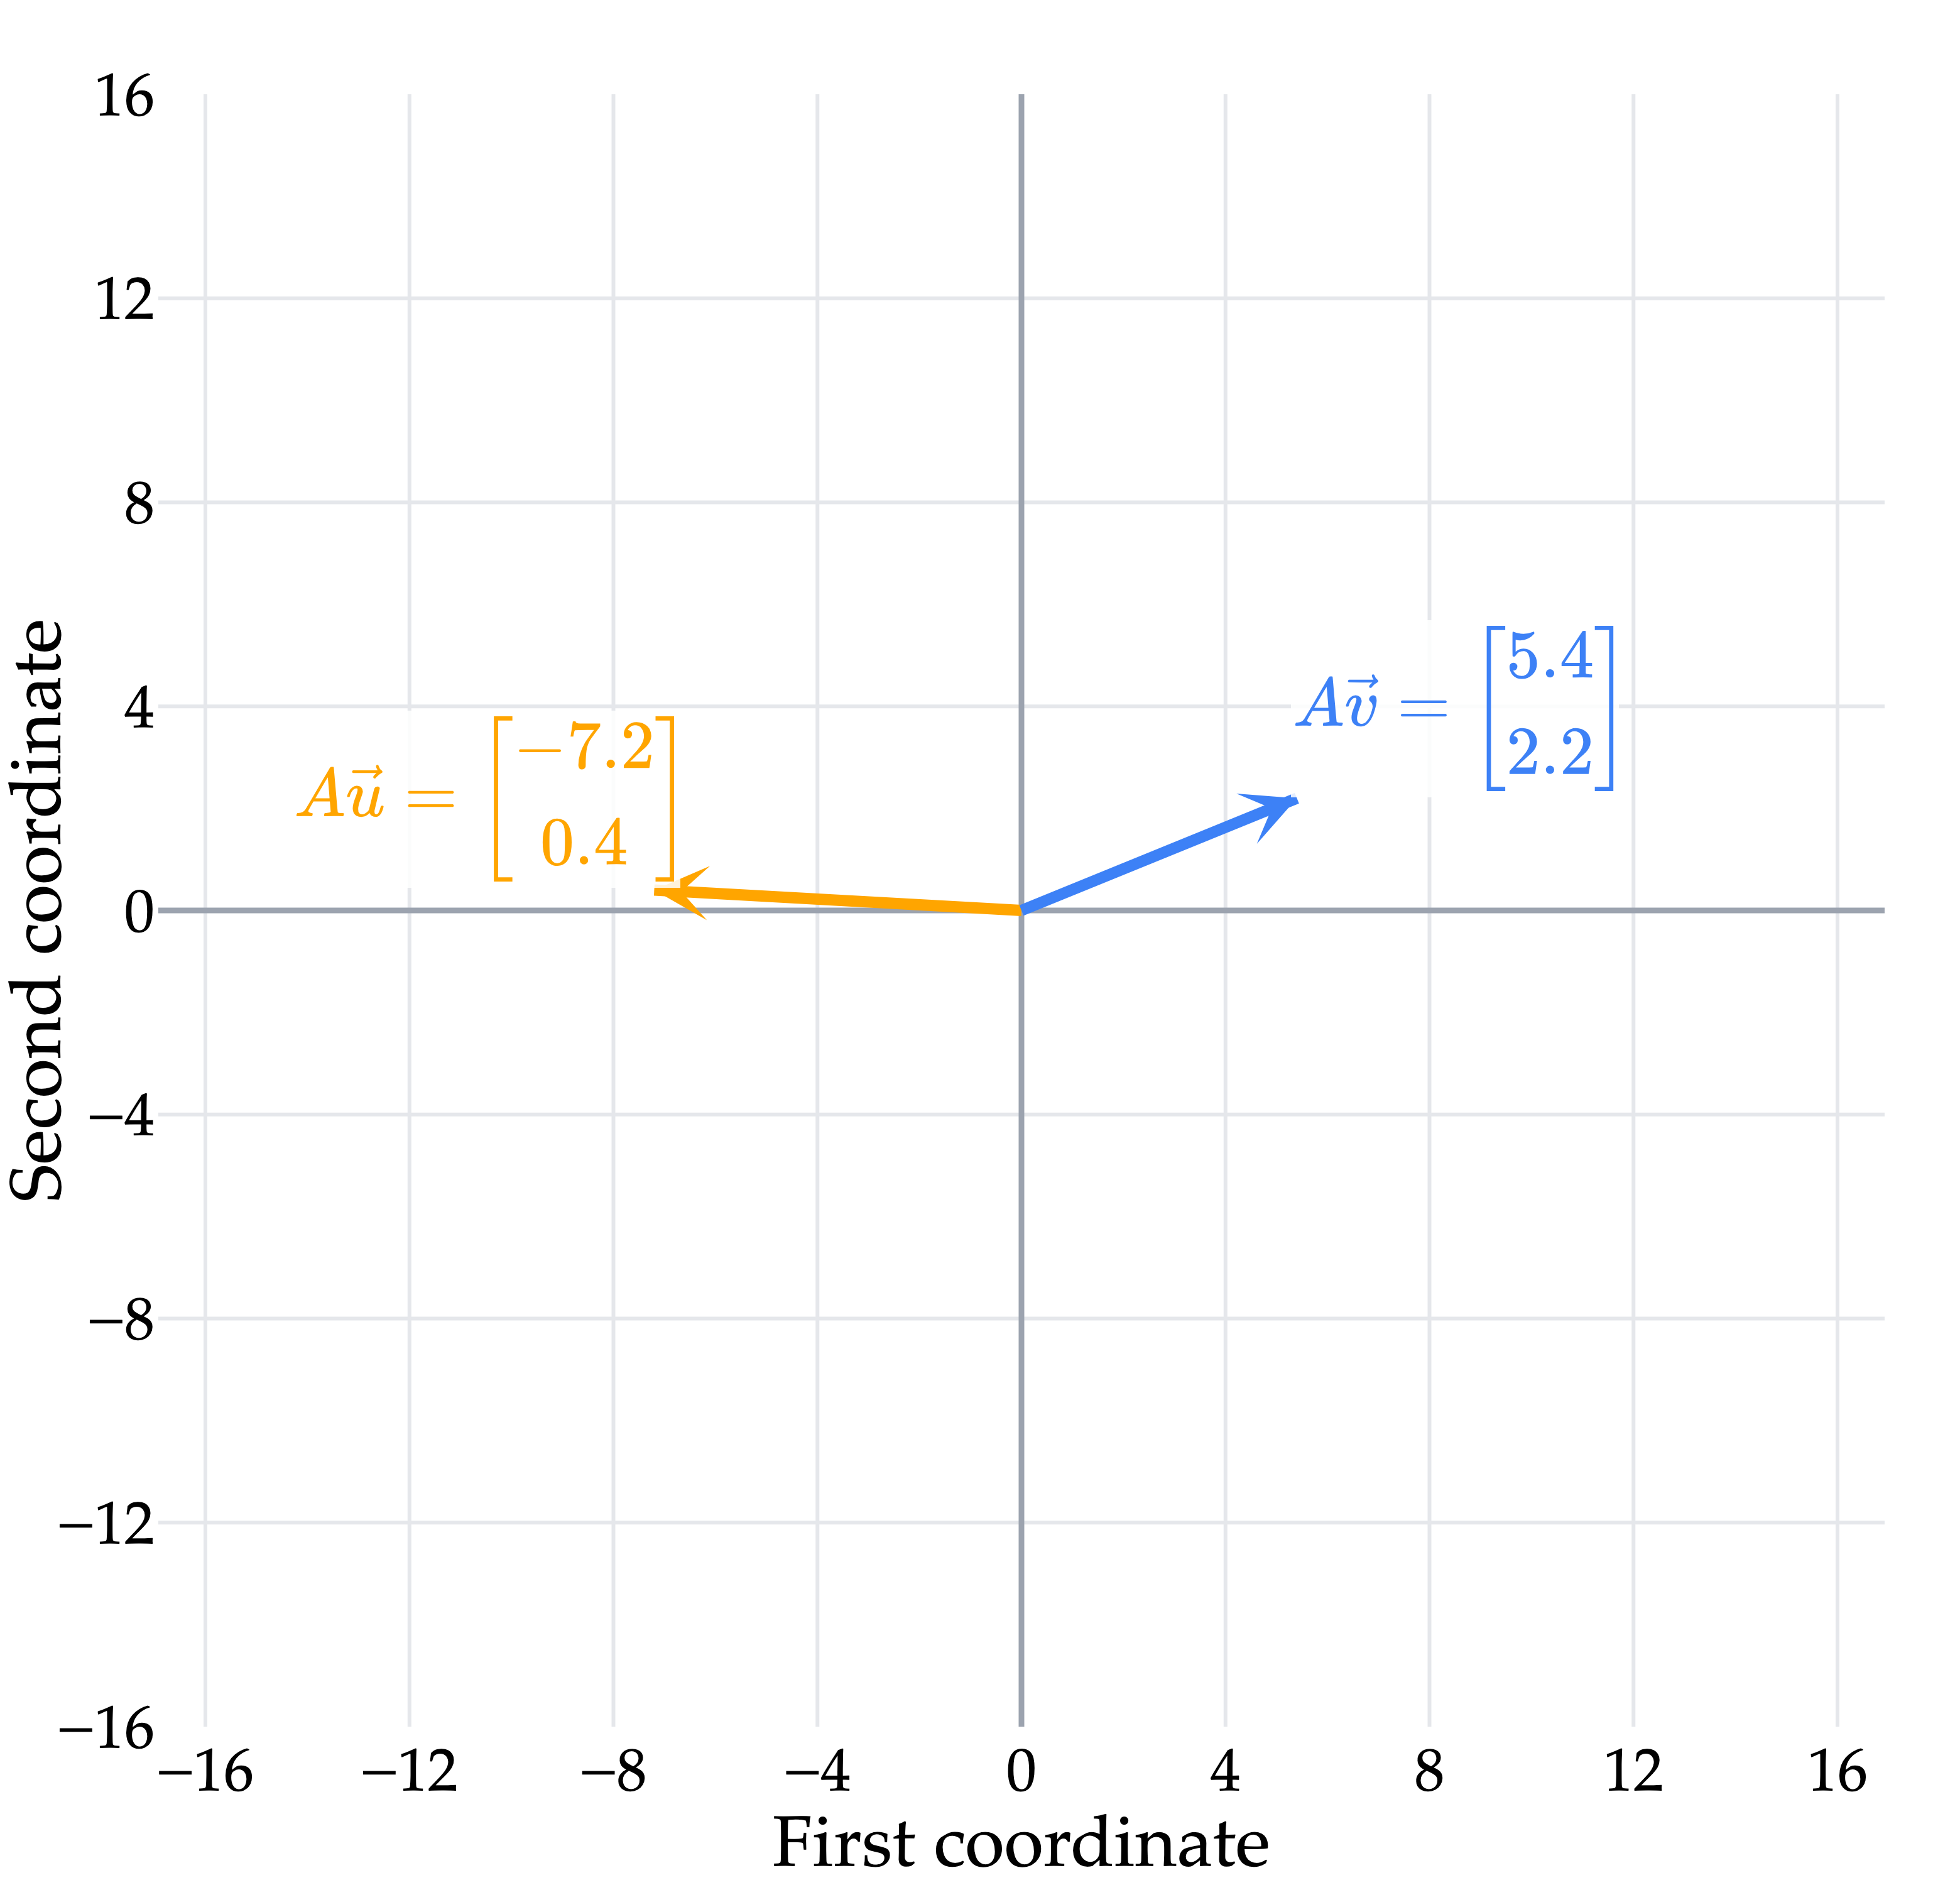

In [7]:
display_pair('transformation-rotation.png', [[-7.2, 0.4], [5.4, 2.2]], [r'A\vec u',r'A\vec v'], limit=16)


This matrix **rotates** every vector counterclockwise by the same angle, approximately $53.1^\circ$, while preserving its length.

$$A\begin{bmatrix}a\\b\end{bmatrix}=\begin{bmatrix}(3a-4b)/5\\(4a+3b)/5\end{bmatrix}.$$

The angle $\theta$ satisfies $\cos\theta=3/5$ and $\sin\theta=4/5$.


---

## Summary

| Example | Matrix | Operation |
| :--- | :--- | :--- |
| 1 | $\begin{bmatrix}1&0\\0&1\end{bmatrix}$ | **Identity:** leaves every vector unchanged. |
| 2 | $\begin{bmatrix}-3/2&0\\0&2\end{bmatrix}$ | **Diagonal:** scales the first coordinate by $-3/2$ and the second by $2$. |
| 3 | $\begin{bmatrix}0&1\\1&0\end{bmatrix}$ | **Permutation:** swaps the coordinates, reflecting across $x_2=x_1$. |
| 4 | $\begin{bmatrix}3&6\\-2&-4\end{bmatrix}$ | Sends every vector onto the line $2x_1+3x_2=0$. |
| 5 | $\begin{bmatrix}3/5&-4/5\\4/5&3/5\end{bmatrix}$ | **Rotation:** turns every vector counterclockwise by about $53.1^\circ$, preserving its length. |


---

## Two questions

1. **Given $A$ and $\vec v$, what is $\vec b=A\vec v$?** Compute the output and describe the operation that $A$ applies to $\vec v$: leaving it unchanged, scaling coordinates, swapping them, sending it onto a line, or rotating it.
2. **Given $A$ and $\vec b$, can we find $\vec v$ such that $A\vec v=\vec b$?** This asks us to work backward from a desired output.

The second question need not have an answer. For the matrix in Example 4,

$$A\begin{bmatrix}a\\b\end{bmatrix}=(a+2b)\begin{bmatrix}3\\-2\end{bmatrix}.$$

The target $\begin{bmatrix}24\\-16\end{bmatrix}$ is reachable: the input $\begin{bmatrix}-4\\6\end{bmatrix}$ produces it. But $\begin{bmatrix}24\\-15\end{bmatrix}$ is unreachable, because every output satisfies $2x+3y=0$. No input can make $A\vec v$ leave that line.

Even when an input exists, it need not be unique: $\begin{bmatrix}8\\0\end{bmatrix}$ also produces $\begin{bmatrix}24\\-16\end{bmatrix}$.
